# Data Exploration and Visualization

##  initial descriptive analysis for the dataset

### Load dataset

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
df = pd.read_csv("C:\hassan\cess\semester 8\ML\project\Stroke-Prediction-ML\data\healthcare-dataset-stroke-data (2).csv")

df.drop('id', axis=1, inplace=True)
df.head()

<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
C:\Users\hassa\AppData\Local\Temp\ipykernel_21324\2116104957.py:10: SyntaxWarning: invalid escape sequence '\h'
  df = pd.read_csv("C:\hassan\cess\semester 8\ML\project\Stroke-Prediction-ML\data\healthcare-dataset-stroke-data (2).csv")


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### info about dataset

In [2]:
df.info()

df.isnull().sum()

df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


## Data visualization

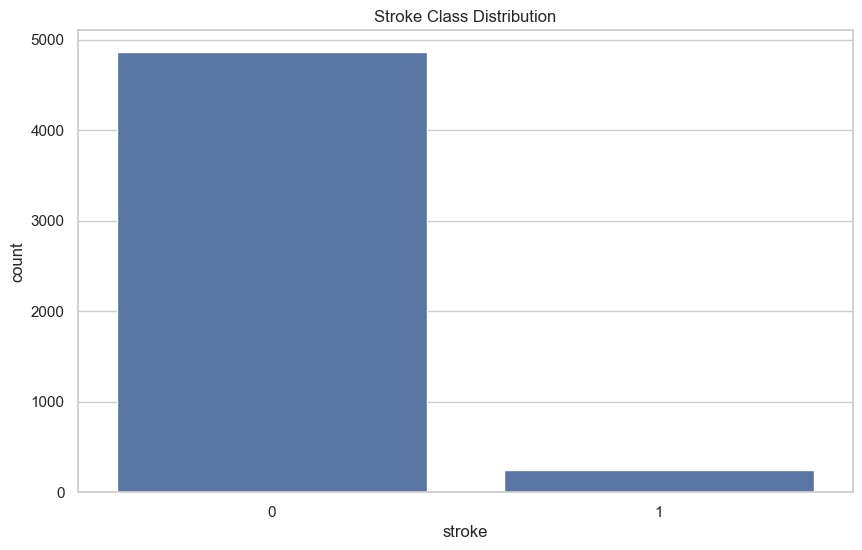

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [3]:
sns.countplot(data=df, x="stroke")
plt.title("Stroke Class Distribution")
plt.show()

stroke_percent = df['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)


In [7]:
!pip install missingno

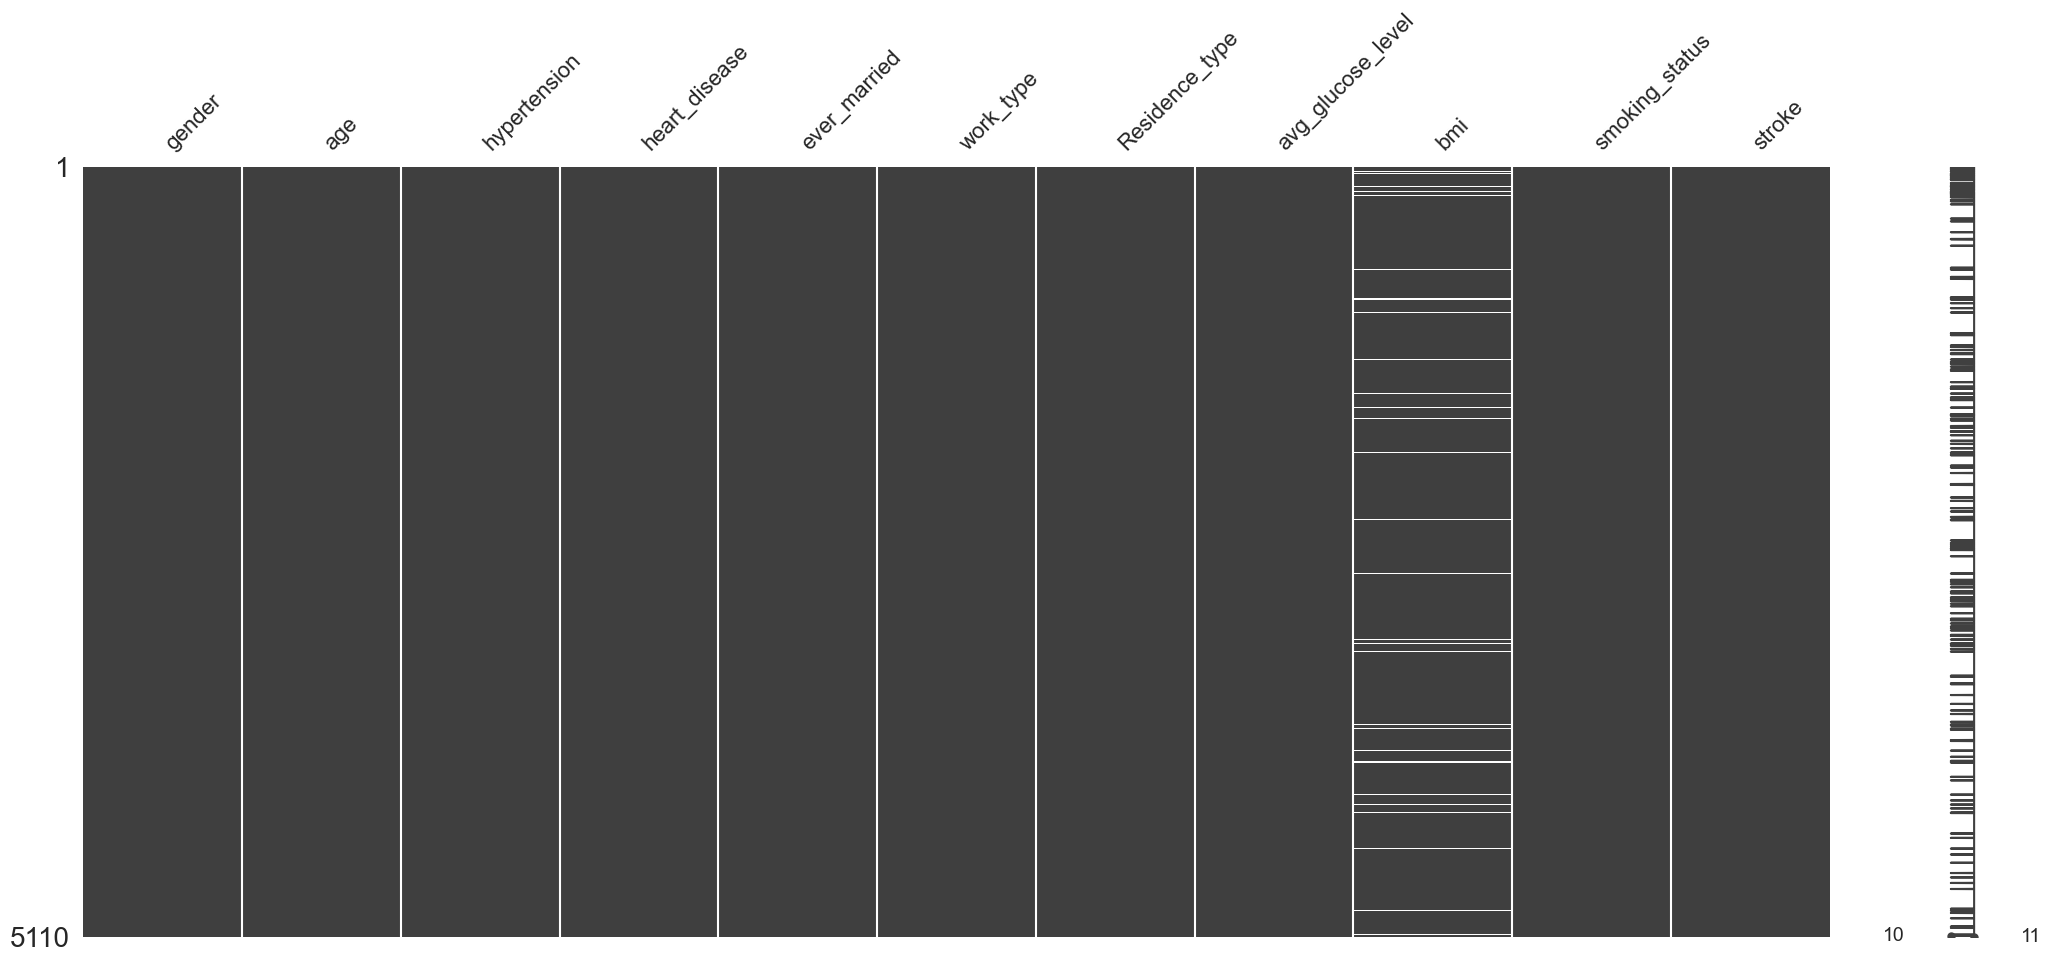

In [8]:
import missingno as msno

msno.matrix(df)
plt.show()


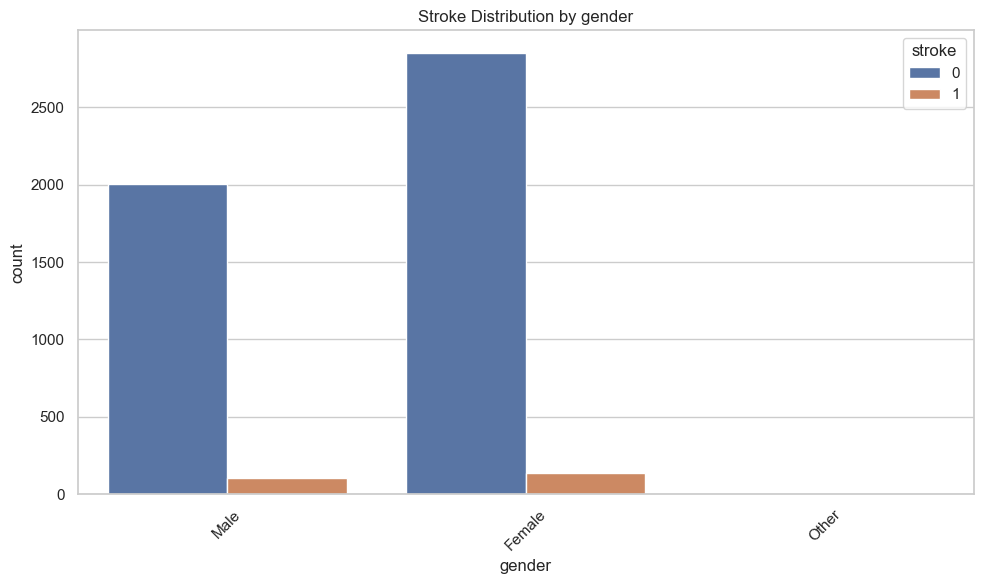

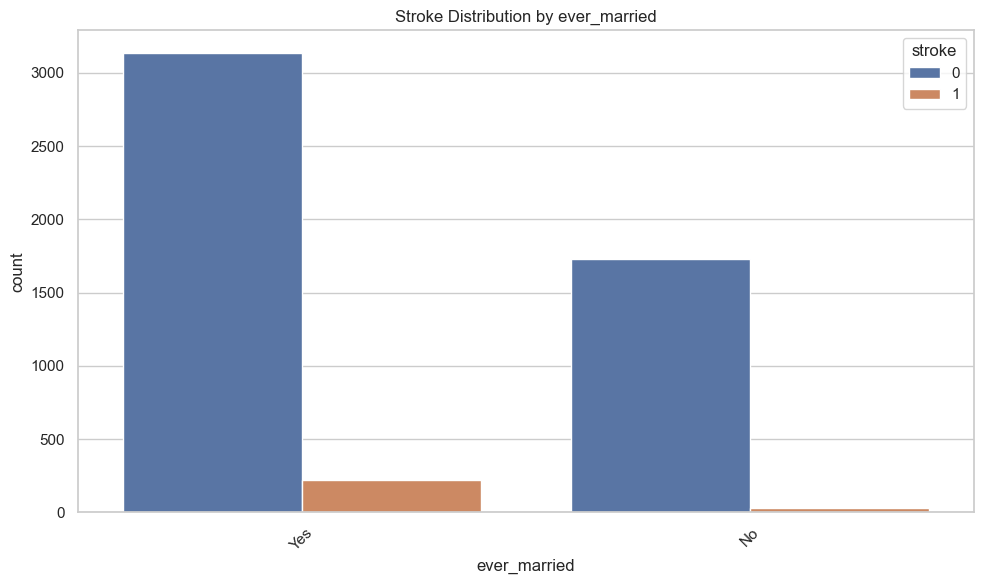

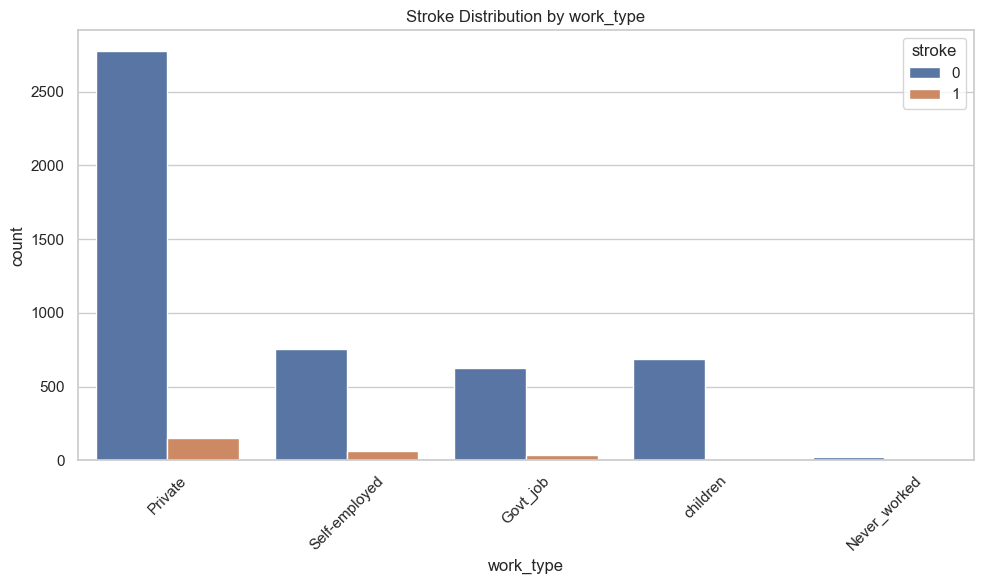

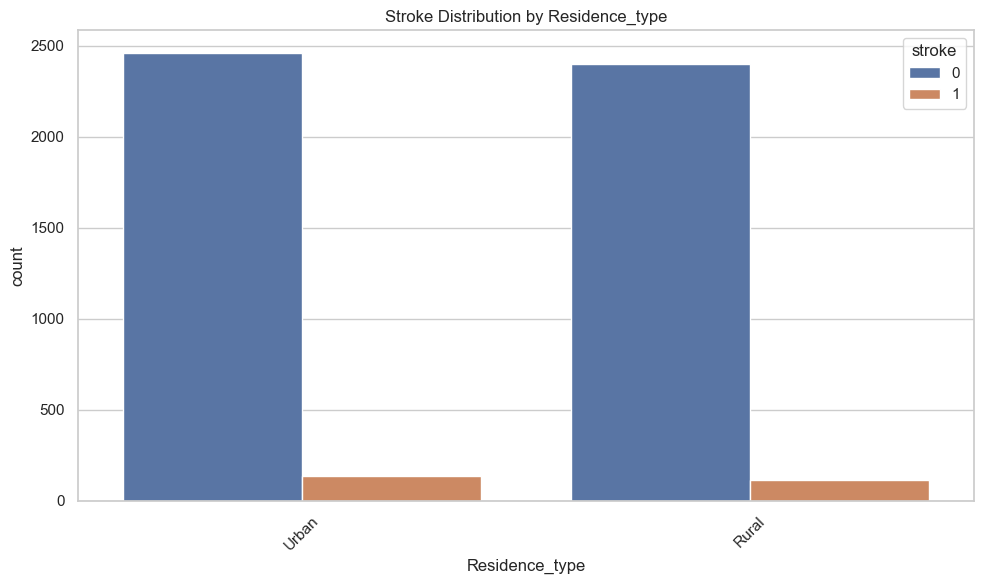

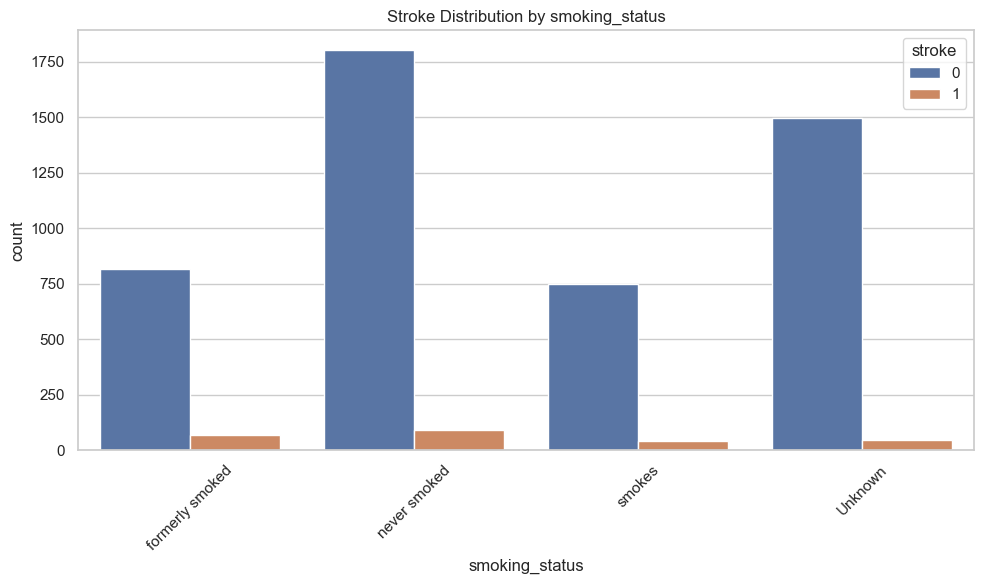

In [9]:
cat_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for col in cat_features:
    sns.countplot(data=df, x=col, hue="stroke")
    plt.title(f"Stroke Distribution by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


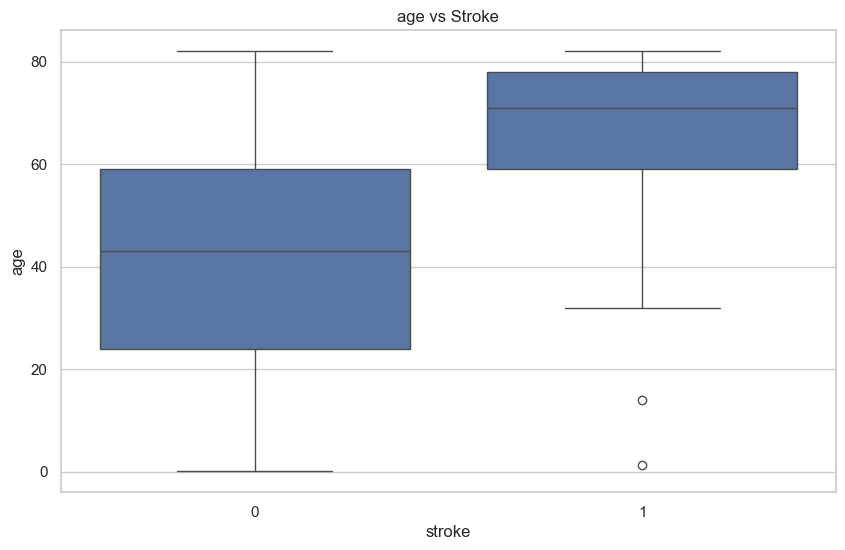

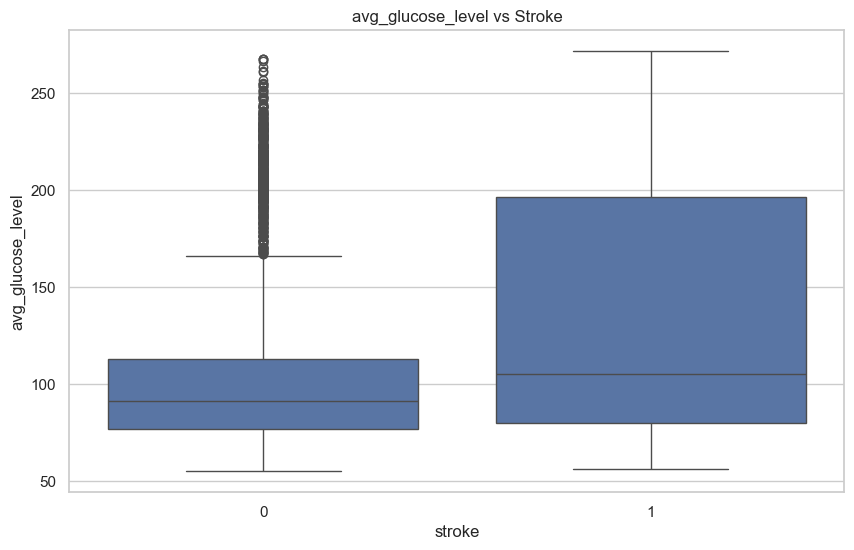

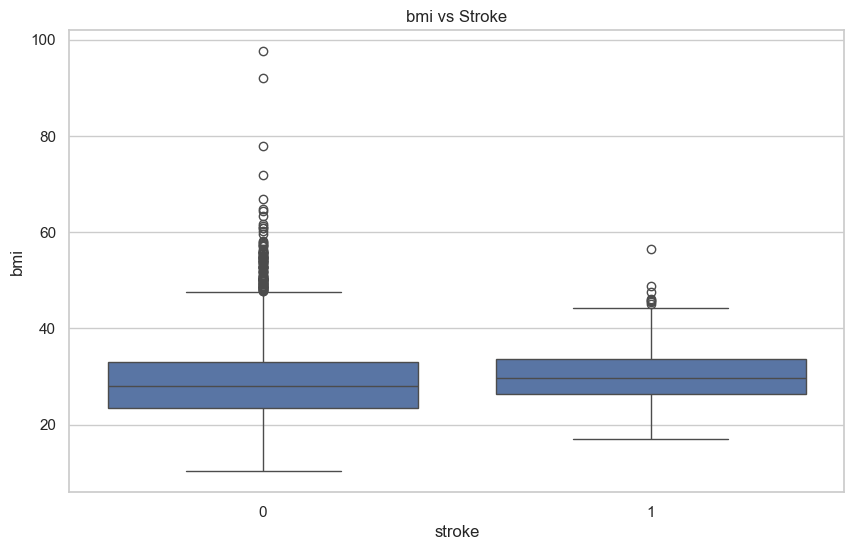

In [10]:
num_features = ["age", "avg_glucose_level", "bmi"]

for col in num_features:
    sns.boxplot(data=df, x="stroke", y=col)
    plt.title(f"{col} vs Stroke")
    plt.show()


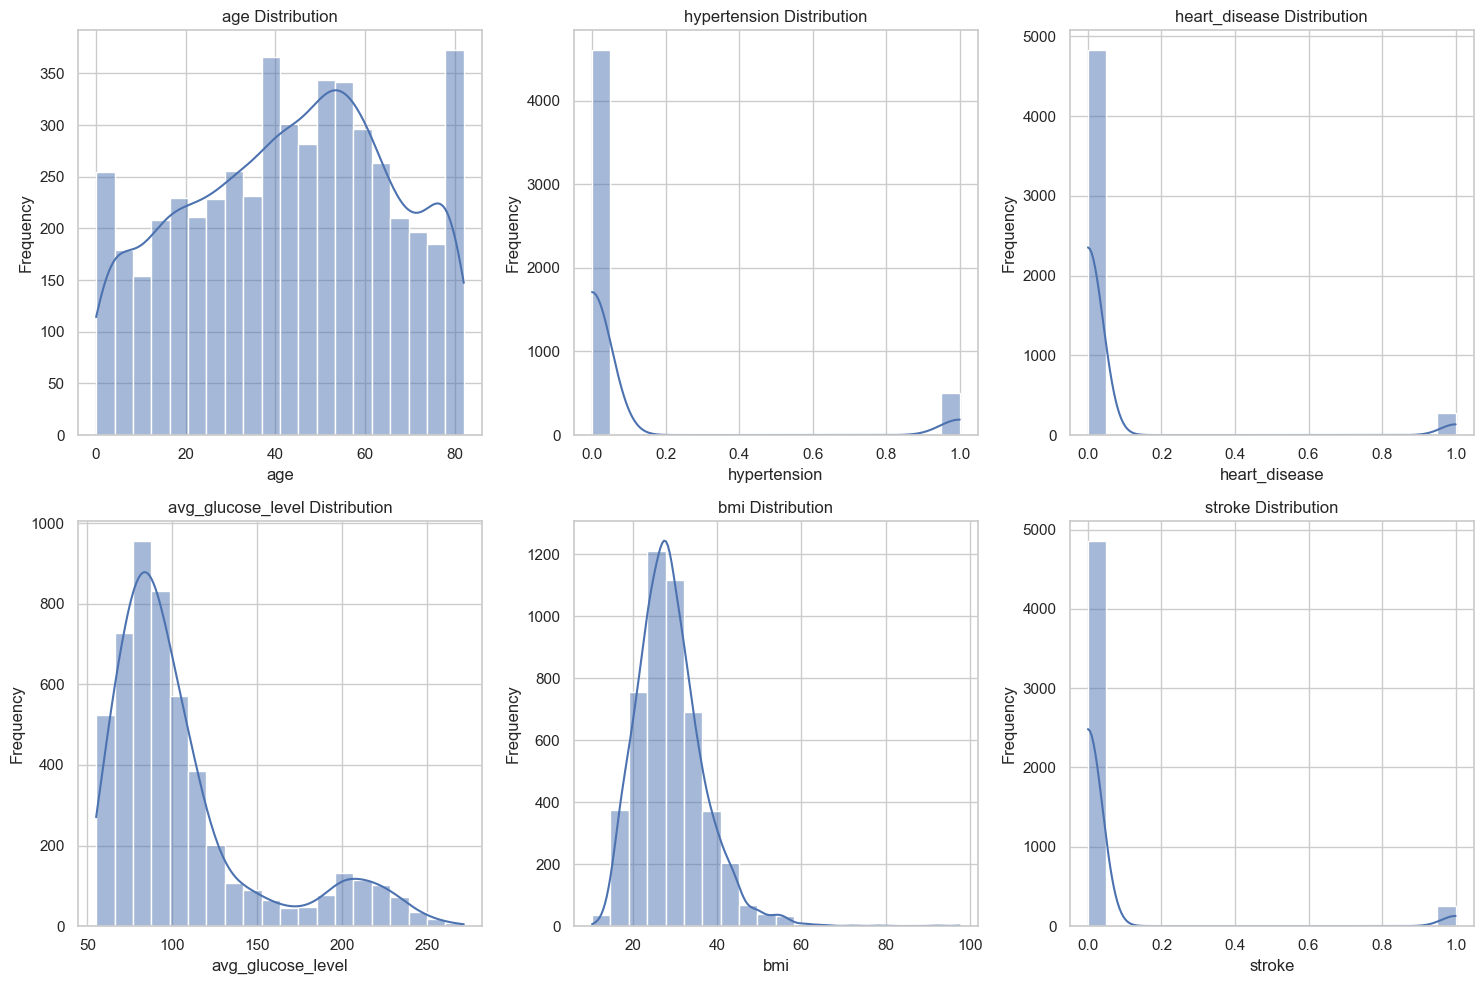

In [11]:
numeric_features = df.select_dtypes(include=['int', 'float']).columns

fig, axes = plt.subplots(nrows=(len(numeric_features) + 2) // 3, ncols=3, figsize=(15, 5 * ((len(numeric_features) + 2) // 3)))
axes = axes.flatten()
for ax, feature in zip(axes, numeric_features):
    sns.histplot(df[feature], bins=20, kde=True, ax=ax)
    ax.set_title(f'{feature} Distribution')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

for i in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

### scatter plots

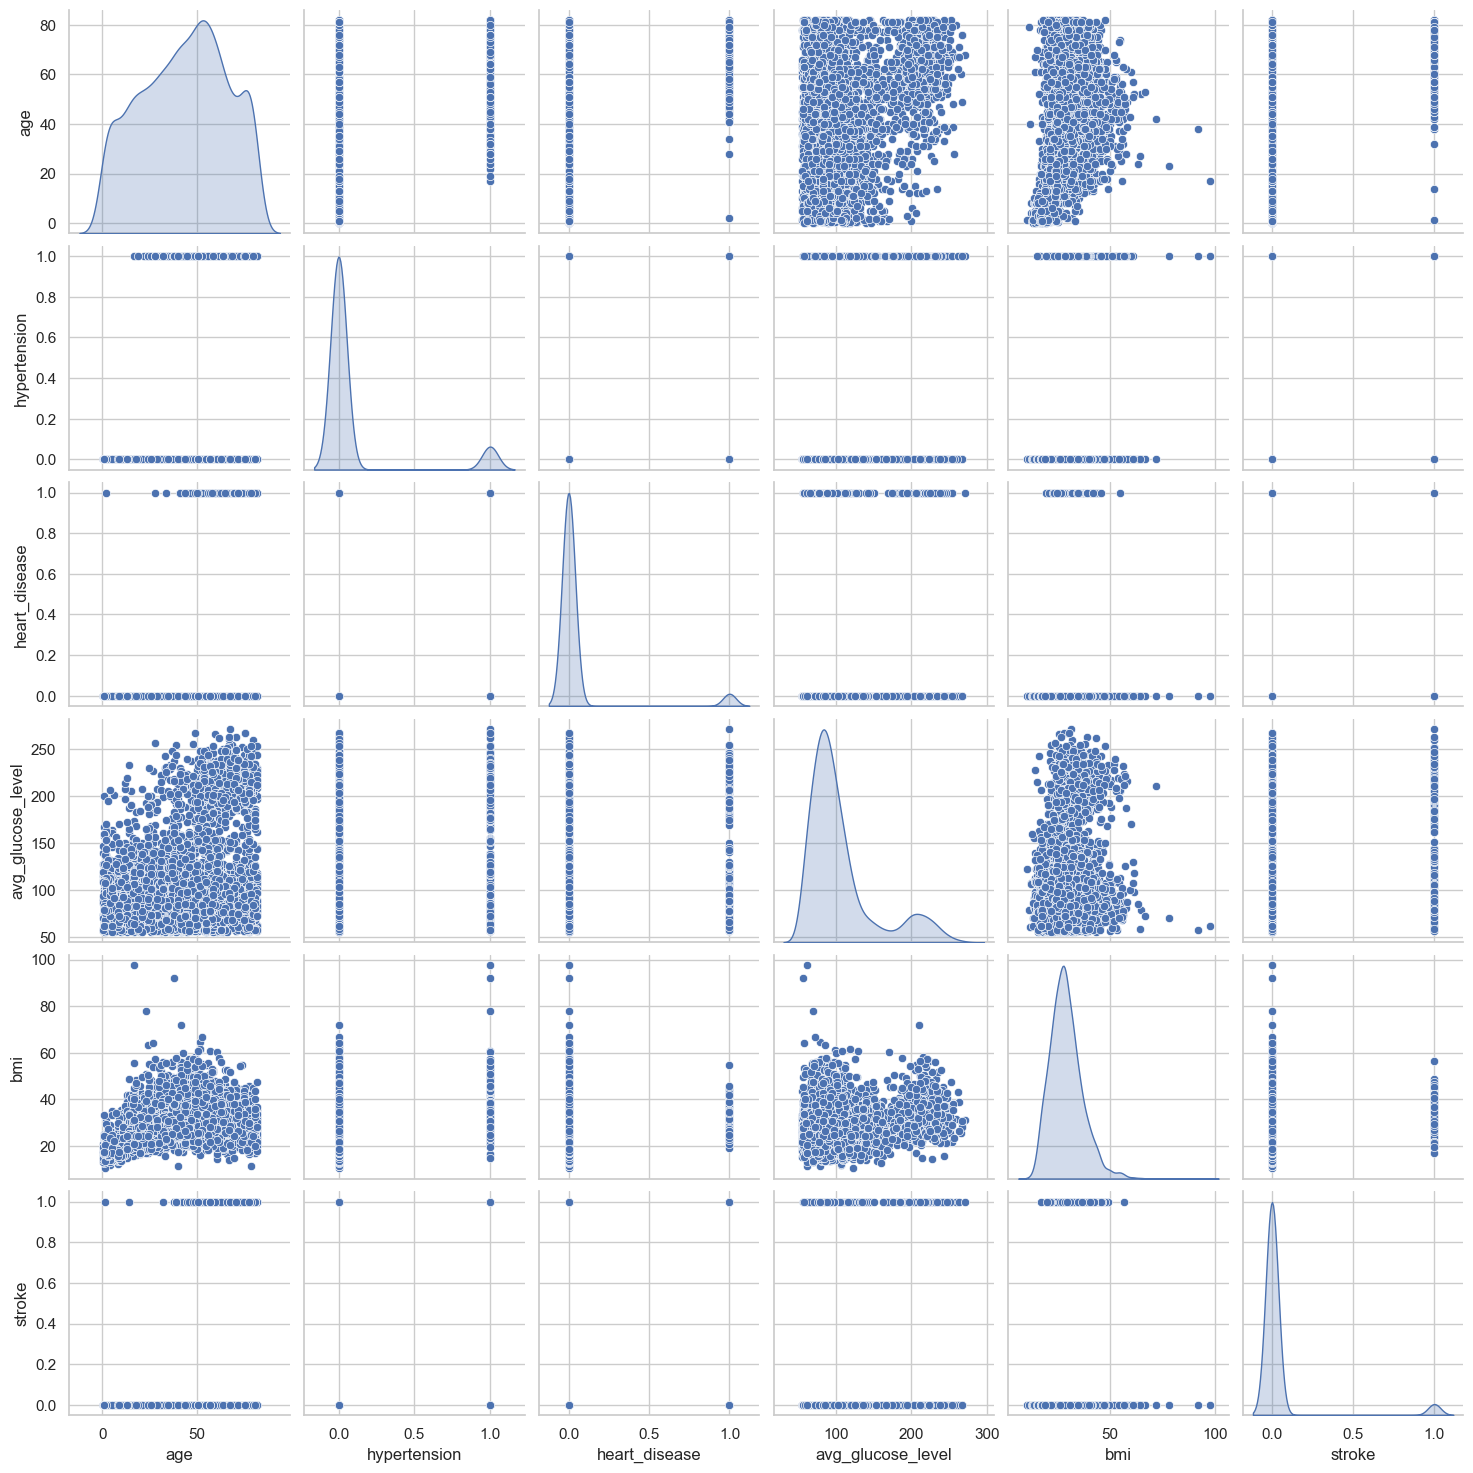

In [12]:
sns.pairplot(df[numeric_features], diag_kind='kde')
plt.show()

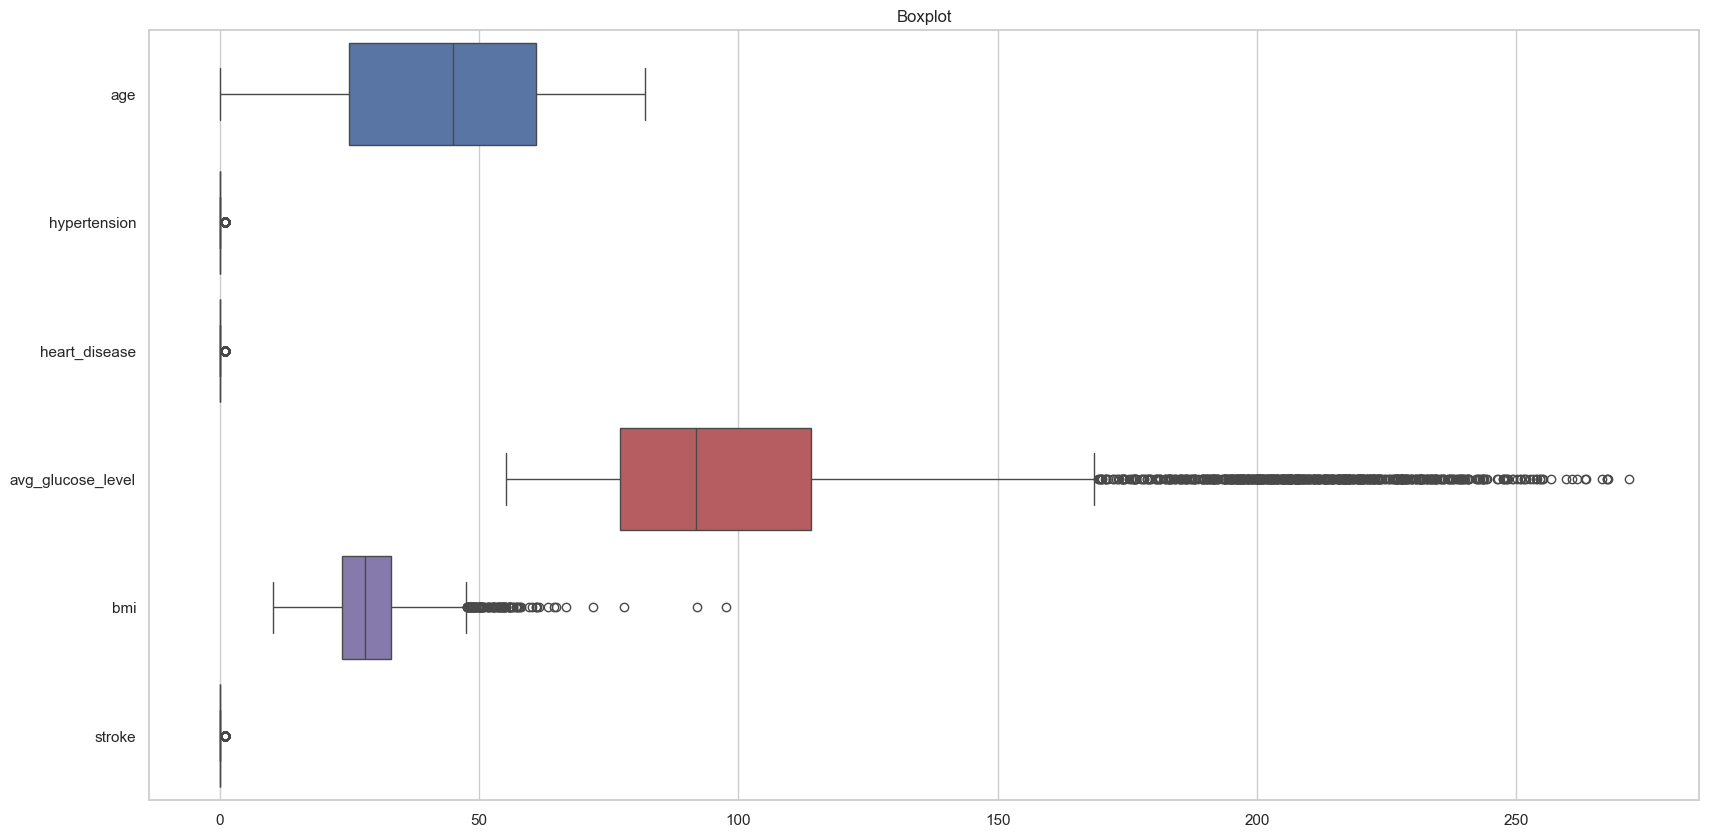

In [13]:
plt.figure(figsize=(20, 10))
sns.boxplot(df, orient='h')
plt.title('Boxplot')
plt.show()

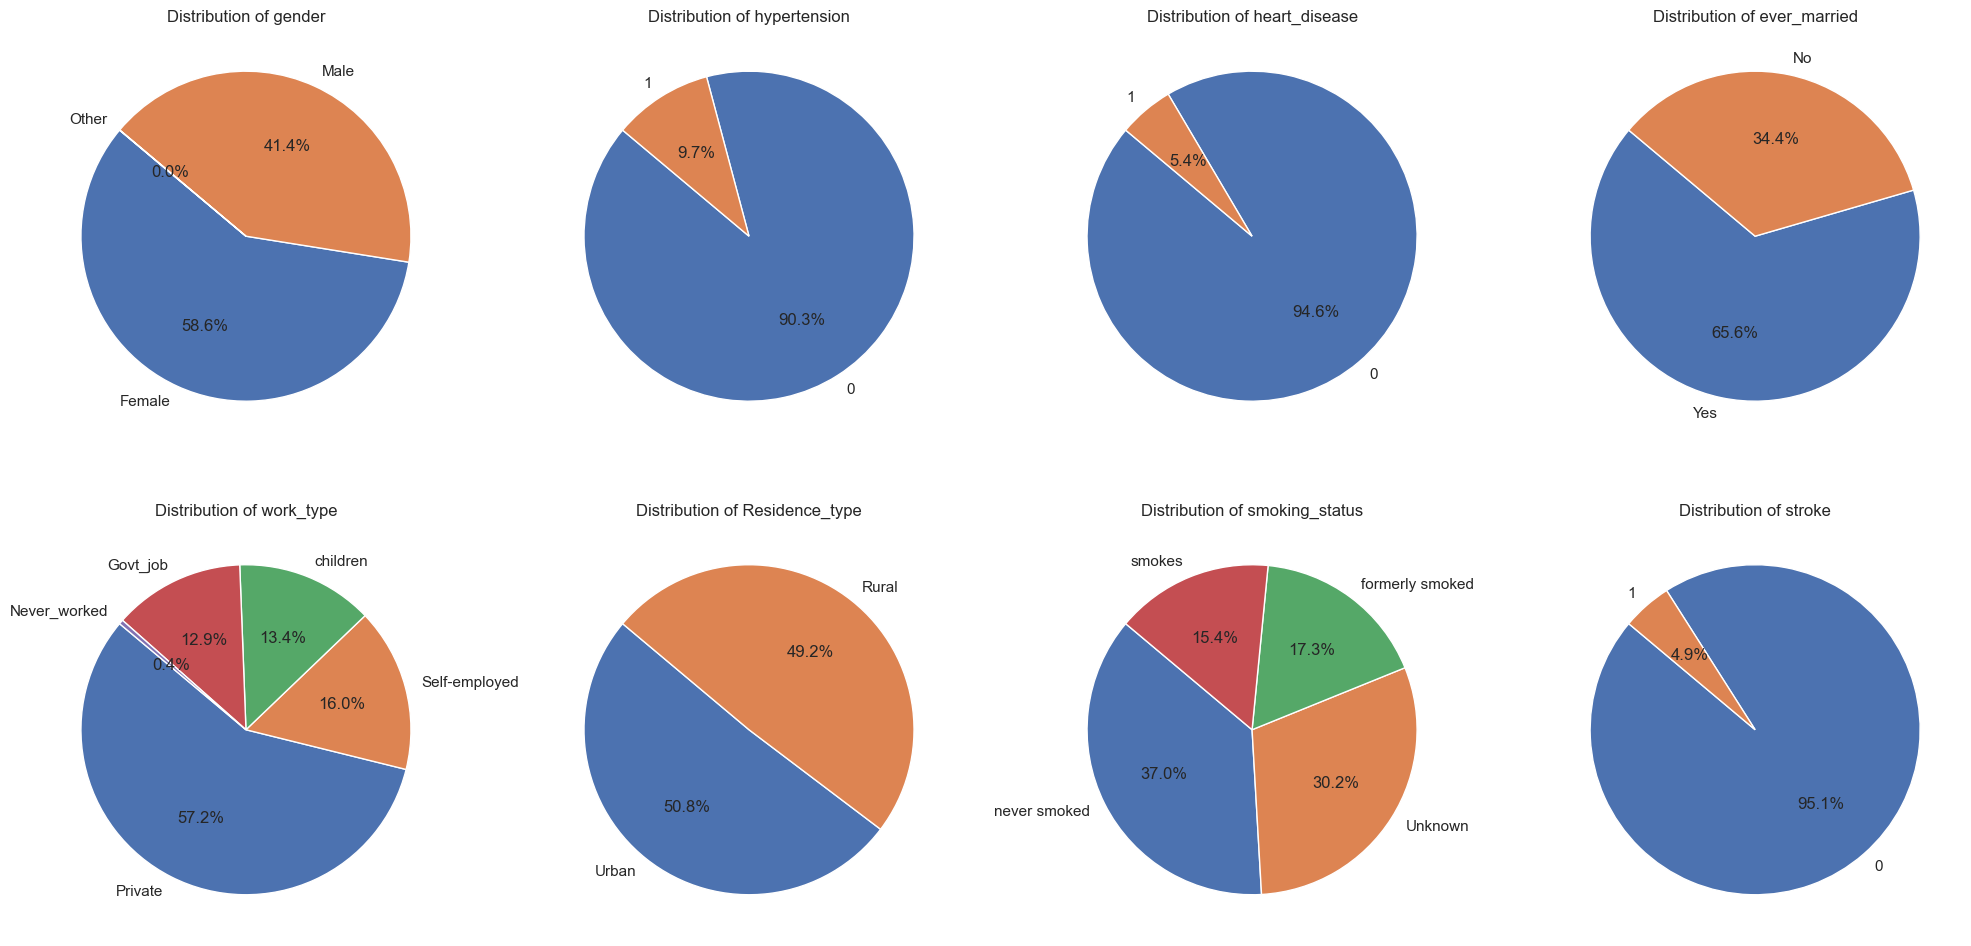

In [14]:
def compact_pie_chart(df, column, ax):
    counts = df[column].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
    ax.set_title(f'Distribution of {column}')

categorical_columns = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'stroke']

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    compact_pie_chart(df, column, ax)

for i in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install tqdm
!pip install ipympl
!pip install mlflow
!pip install scipy
!pip install h2o
!pip install ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.7/515.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.0/700.0 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.

In [17]:
!pip install --upgrade setuptools

  Using cached setuptools-80.1.0-py3-none-any.whl.metadata (6.5 kB)
Using cached setuptools-80.1.0-py3-none-any.whl (1.2 MB)


In [19]:
!pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 212.4 kB/s eta 0:11:44
   ---------------------------------------- 0.5/150.0 MB 212.4 kB/s eta 0:11:44
   ---------------------------------------- 0.5/150.0 MB 212.4 kB/s eta 0:11:44
   ---------------------------------------- 0.5/150.0 MB 212.4 kB/s eta 0:11:44
   --------------------------------------

In [3]:
import os
import shutil
import joblib

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder,StandardScaler, MinMaxScaler, RobustScaler

from sklearn.metrics import classification_report,accuracy_score, confusion_matrix, roc_auc_score, roc_curve, auc, f1_score, precision_score, recall_score

from sklearn.decomposition import PCA

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, cross_val_predict, cross_validate, train_test_split

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB,BernoulliNB,CategoricalNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid
from sklearn.decomposition import LatentDirichletAllocation as LDA
import h2o
from h2o.automl import H2OAutoML
from ydata_profiling import ProfileReport
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import optuna
from optuna.integration import OptunaSearchCV
from optuna.distributions import FloatDistribution

## dealing with missing values

### removing rows with missing bmi value

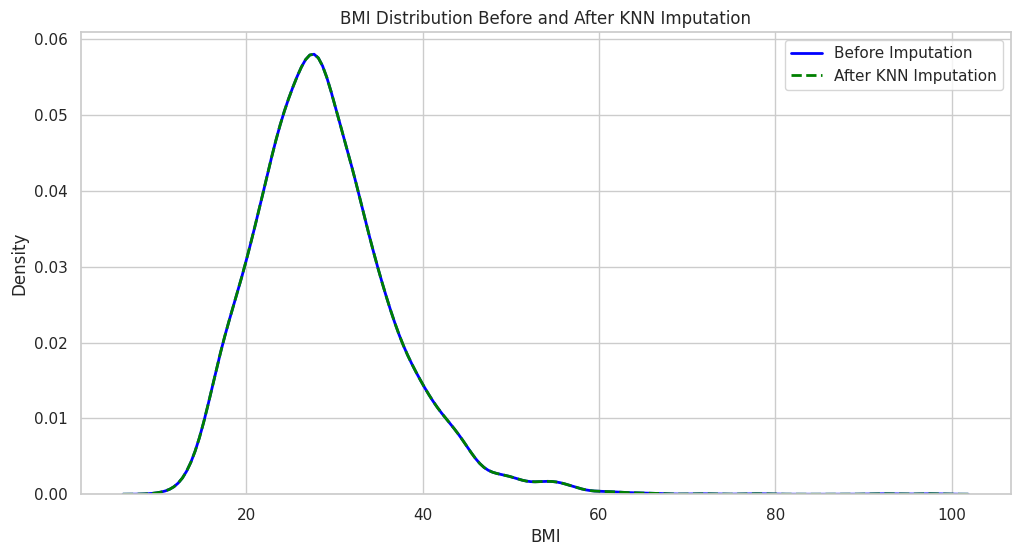

Before Imputation:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

After Imputation:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64
stroke
0    95.742514
1     4.257486
Name: proportion, dtype: float64


In [ ]:
df_clean = df.copy()
df_clean = df.dropna(subset=['bmi'])

bmi_before = df['bmi'].dropna()

bmi_after = df_clean['bmi']

plt.figure(figsize=(12, 6))
sns.kdeplot(bmi_before, label='Before Imputation', color='blue', linewidth=2)
sns.kdeplot(bmi_after, label='After KNN Imputation', color='green', linestyle='--', linewidth=2)
plt.title('BMI Distribution Before and After KNN Imputation')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

print("Before Imputation:")
print(bmi_before.describe())
print("\nAfter Imputation:")
print(bmi_after.describe())

stroke_percent = df_clean['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)

stroke percentage dropped after removing lines with bmi nan value

### filling missing value by using median

<ipython-input-16-63bb1ba89d21>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['bmi'].fillna(df_clean['bmi'].median(), inplace=True)


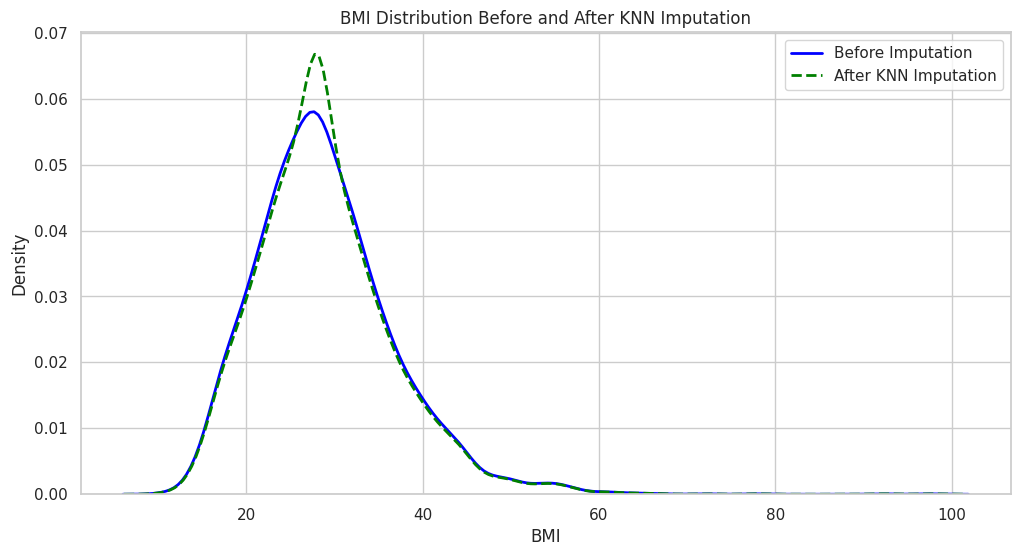

Before Imputation:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

After Imputation:
count    5110.000000
mean       28.862035
std         7.699562
min        10.300000
25%        23.800000
50%        28.100000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [ ]:
df_clean = df.copy()
df_clean['bmi'].fillna(df_clean['bmi'].median(), inplace=True)

bmi_after = df_clean['bmi']

plt.figure(figsize=(12, 6))
sns.kdeplot(bmi_before, label='Before Imputation', color='blue', linewidth=2)
sns.kdeplot(bmi_after, label='After KNN Imputation', color='green', linestyle='--', linewidth=2)
plt.title('BMI Distribution Before and After KNN Imputation')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

print("Before Imputation:")
print(bmi_before.describe())
print("\nAfter Imputation:")
print(bmi_after.describe())

stroke_percent = df_clean['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)

difference in mean is large so is std

### filling missing value by using mean

<ipython-input-21-7df06fd5388c>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['bmi'].fillna(df_clean['bmi'].mean(), inplace=True)


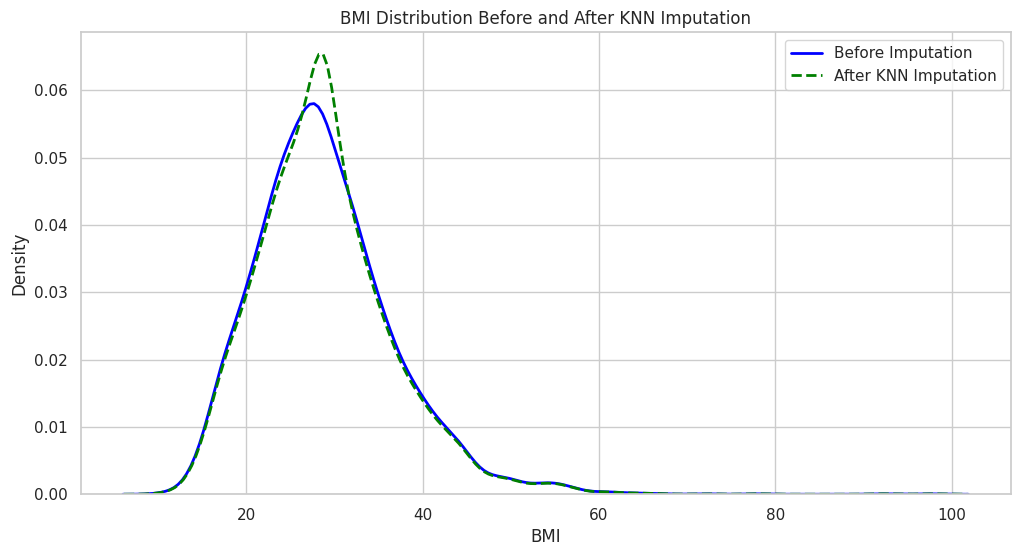

Before Imputation:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

After Imputation:
count    5110.000000
mean       28.893237
std         7.698018
min        10.300000
25%        23.800000
50%        28.400000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [ ]:
df_clean = df.copy()
df_clean['bmi'].fillna(df_clean['bmi'].mean(), inplace=True)

bmi_after = df_clean['bmi']

plt.figure(figsize=(12, 6))
sns.kdeplot(bmi_before, label='Before Imputation', color='blue', linewidth=2)
sns.kdeplot(bmi_after, label='After KNN Imputation', color='green', linestyle='--', linewidth=2)
plt.title('BMI Distribution Before and After KNN Imputation')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

print("Before Imputation:")
print(bmi_before.describe())
print("\nAfter Imputation:")
print(bmi_after.describe())

stroke_percent = df_clean['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)

difference in std is large so is 25, 50 and 75%

### filling missing value by using KNN

In [6]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

df_clean = df.copy()


knn_features = df_clean[['age', 'avg_glucose_level', 'bmi']].copy()

knn_features['bmi'] = knn_features['bmi'].astype(float)

scaler = StandardScaler()
knn_scaled = scaler.fit_transform(knn_features)

imputer = KNNImputer(n_neighbors=5)
knn_imputed = imputer.fit_transform(knn_scaled)

knn_inverse = scaler.inverse_transform(knn_imputed)

df_clean['bmi'] = knn_inverse[:, 2]

print(f"Missing BMI values after KNN imputation: {df_clean['bmi'].isnull().sum()}")


Missing BMI values after KNN imputation: 0


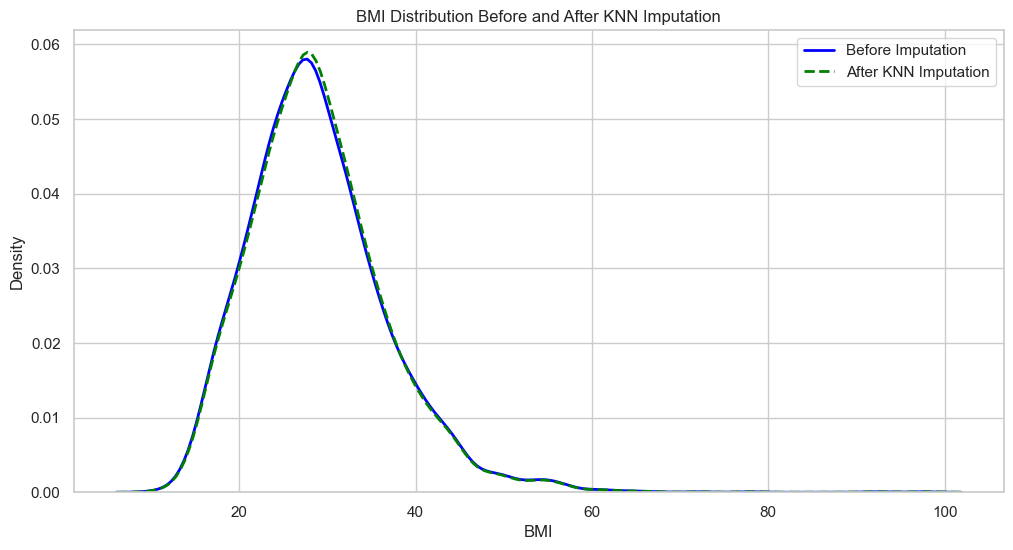

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

bmi_before = df['bmi'].dropna()

bmi_after = df_clean['bmi']

plt.figure(figsize=(12, 6))
sns.kdeplot(bmi_before, label='Before Imputation', color='blue', linewidth=2)
sns.kdeplot(bmi_after, label='After KNN Imputation', color='green', linestyle='--', linewidth=2)
plt.title('BMI Distribution Before and After KNN Imputation')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


In [23]:
print("Before Imputation:")
print(bmi_before.describe())
print("\nAfter Imputation:")
print(bmi_after.describe())

stroke_percent = df_clean['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)

Before Imputation:
count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

After Imputation:
count    5110.000000
mean       28.950661
std         7.763918
min        10.300000
25%        23.700000
50%        28.200000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


difference in mean and std is minimal and percentage remained the same

## PCA

In [ ]:
def apply_PCA(n_components, df_clean):
    pca = PCA(n_components=n_components)
    pca_df_clean = pca.fit_transform(df_clean)
    return pca_df_clean, pca

In [ ]:
def pca(n_components, df_clean):
    pca_df_clean, pca = apply_PCA(n_components, df_clean)
    print('Explained Variance Ratio :',pca.explained_variance_ratio_)
    print('Explained Variance :',pca.explained_variance_)
    return pca_df_clean,pca

In [ ]:
def plot_2d(df_clean):

    numeric_columns = df_clean.select_dtypes(include=['number']).columns
    if len(numeric_columns) >= 2:

        plt.figure(figsize=(8, 6))
        plt.scatter(df_clean[numeric_columns[0]], df_clean[numeric_columns[1]], c='blue', alpha=0.6)
        plt.title(f"2D Scatter Plot ({numeric_columns[0]} vs {numeric_columns[1]})")
        plt.xlabel(numeric_columns[0])
        plt.ylabel(numeric_columns[1])
        plt.grid(True)
        plt.show()
    else:
        print("The DataFrame must have at least 2 numerical columns for plotting.")


In [ ]:
PCA_2D=PCA(n_components=2)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_encoded = df_clean.copy()

categorical_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

le = LabelEncoder()

for column in categorical_columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

# Verify encoding
print(df_encoded.head())

   gender   age  hypertension  heart_disease  ever_married  work_type  \
0       1  67.0             0              1             1          2   
1       0  61.0             0              0             1          3   
2       1  80.0             0              1             1          2   
3       0  49.0             0              0             1          2   
4       0  79.0             1              0             1          3   

   Residence_type  avg_glucose_level    bmi  smoking_status  stroke  
0               1             228.69  36.60               1       1  
1               0             202.21  31.14               2       1  
2               0             105.92  32.50               2       1  
3               1             171.23  34.40               3       1  
4               0             174.12  24.00               2       1  


In [ ]:
data_PCA_2D,PCA_2D=apply_PCA(2,df_encoded)

In [ ]:
PCA_2D.explained_variance_ratio_

array([0.79641161, 0.18260617])

In [ ]:
data_PCA_2D = pd.DataFrame(data_PCA_2D, columns=['PCA_F1','PCA_F2'])
data_PCA_2D['stroke'] = df_encoded['stroke'].values

In [ ]:
data_PCA_2D.head()

,PCA_F1,PCA_F2,stroke
0,124.935862,4.953680,1
1,97.669056,2.600565,1
2,5.562133,36.521226,1
3,65.352460,-3.905731,1
4,72.446502,23.857870,1


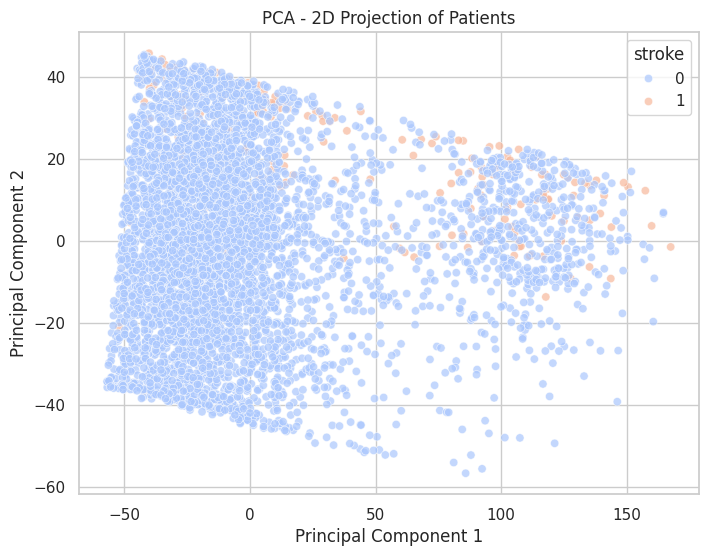

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=data_PCA_2D['PCA_F1'], y=data_PCA_2D['PCA_F2'], hue=data_PCA_2D['stroke'], palette='coolwarm', alpha=0.7)
plt.title("PCA - 2D Projection of Patients")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [ ]:
def plot_PCA_2D(data, columns, target):
    # Apply PCA
    pca = PCA(n_components=1)
    pca_data = pca.fit_transform(data[columns])
    pca_df = pd.DataFrame(pca_data, columns=['PCA_1D'])
    pca_df[target] = data[target].values

    # Plot before PCA
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    # scatterplot returns an object that can be used to create a colorbar
    scatter = sns.scatterplot(x=data[columns[0]], y=data[columns[1]], hue=data[target], palette='coolwarm', alpha=0.7)

    plt.title("Before PCA")
    plt.xlabel(columns[0])
    plt.ylabel(columns[1])
    # Use the scatterplot object to create the colorbar
    plt.colorbar(scatter.collections[0], label=target)
    plt.grid(True)

    # Plot after PCA
    plt.subplot(1, 2, 2)
    # scatterplot returns an object that can be used to create a colorbar
    scatter = sns.scatterplot(x=pca_df['PCA_1D'], y=pca_df[target], hue=pca_df[target], palette='coolwarm', alpha=0.7)

    plt.title("After PCA")
    plt.xlabel('PCA_1D')
    plt.ylabel(target)
    # Use the scatterplot object to create the colorbar
    plt.colorbar(scatter.collections[0], label=target)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

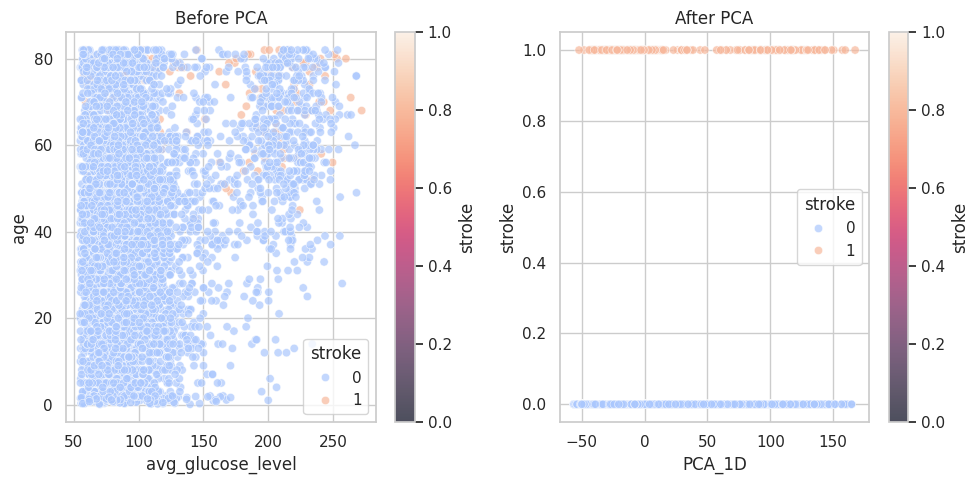

In [ ]:
plot_PCA_2D(df_clean,['avg_glucose_level','age'],'stroke')

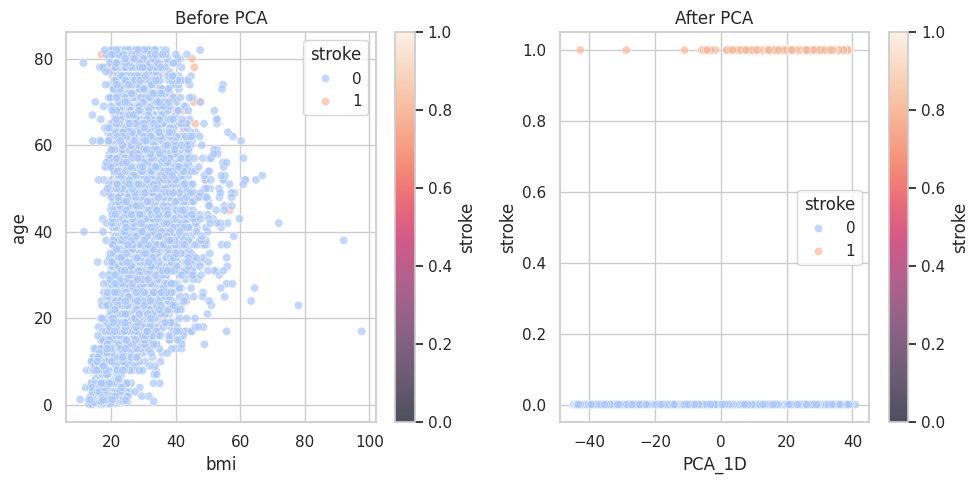

In [ ]:
plot_PCA_2D(df_clean,['bmi','age'],'stroke')

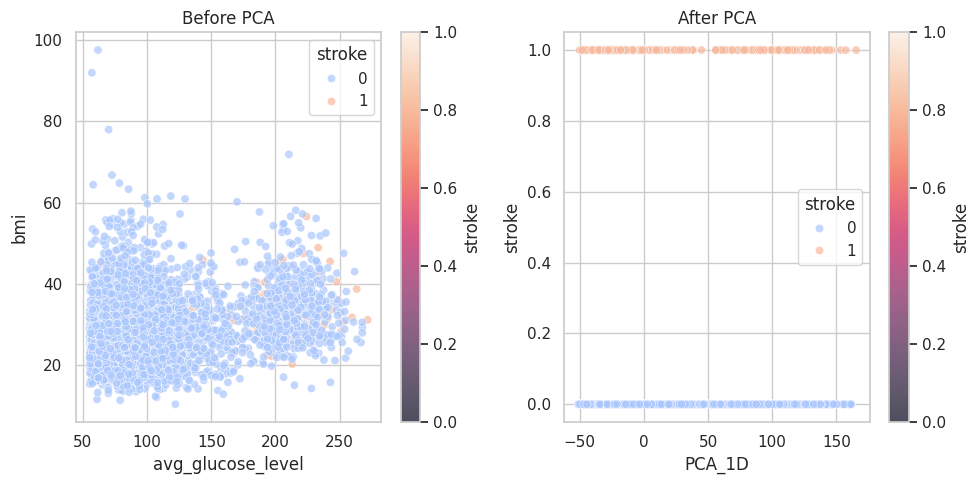

In [ ]:
plot_PCA_2D(df_clean,['avg_glucose_level','bmi'],'stroke')

## LDA

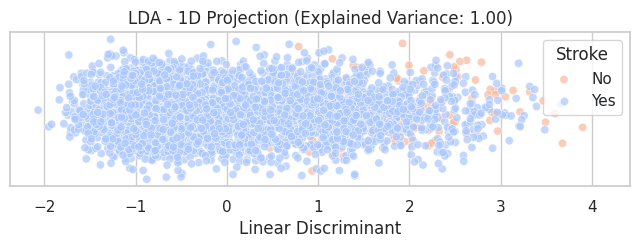

In [ ]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

X = df_clean.drop('stroke', axis=1)
y = df_clean['stroke']

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

numerical_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Apply LDA
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)

explained_variance = lda.explained_variance_ratio_[0]

plt.figure(figsize=(8, 2))
jitter_y = np.random.normal(0, 0.05, size=len(X_lda))
sns.scatterplot(
    x=X_lda[:, 0],
    y=jitter_y,
    hue=y,
    palette='coolwarm',
    alpha=0.7,
)
plt.title(f"LDA - 1D Projection (Explained Variance: {explained_variance:.2f})")
plt.xlabel("Linear Discriminant")
plt.yticks([])
plt.grid(True)
plt.legend(title='Stroke', labels=['No', 'Yes'])
plt.show()

## t-SNE

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


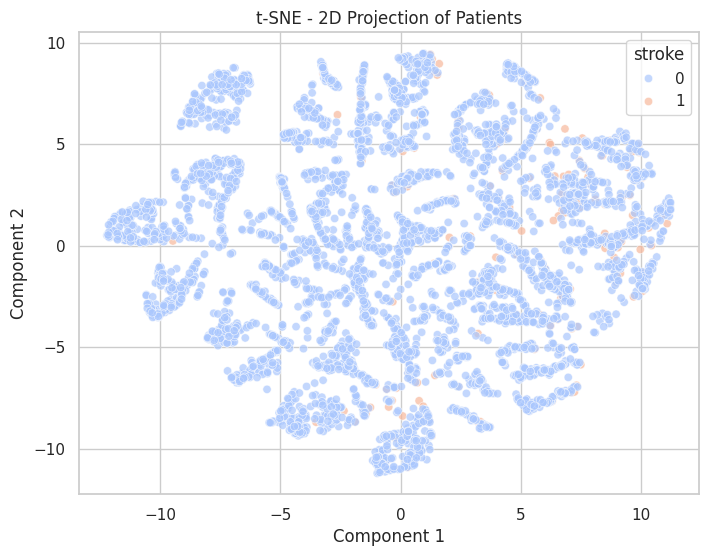

In [ ]:
from sklearn.manifold import TSNE


X_pca_50 = PCA(n_components=min(50, X.shape[1])).fit_transform(X)

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
X_tsne = tsne.fit_transform(X_pca_50)

# Plot t-SNE result
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='coolwarm', alpha=0.7)
plt.title("t-SNE - 2D Projection of Patients")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

## dealing with outliers

In [7]:
# Function to remove outliers using IQR, keeping stroke=1 rows
def remove_outliers(df_clean, col):
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter only rows that are within bounds OR have stroke == 1
    return df_clean[
        (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound) | (df_clean['stroke'] == 1)
    ]
numerical_cols = ['age', 'avg_glucose_level', 'bmi']



# Remove outliers for numerical features
for col in numerical_cols:
    df_clean = remove_outliers(df_clean, col)

### visualization after removing outliers

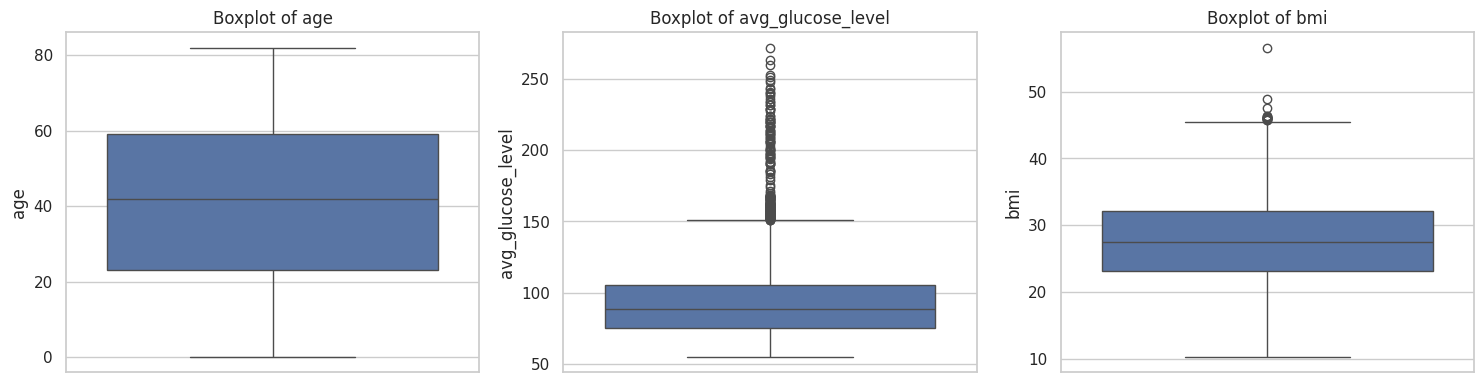

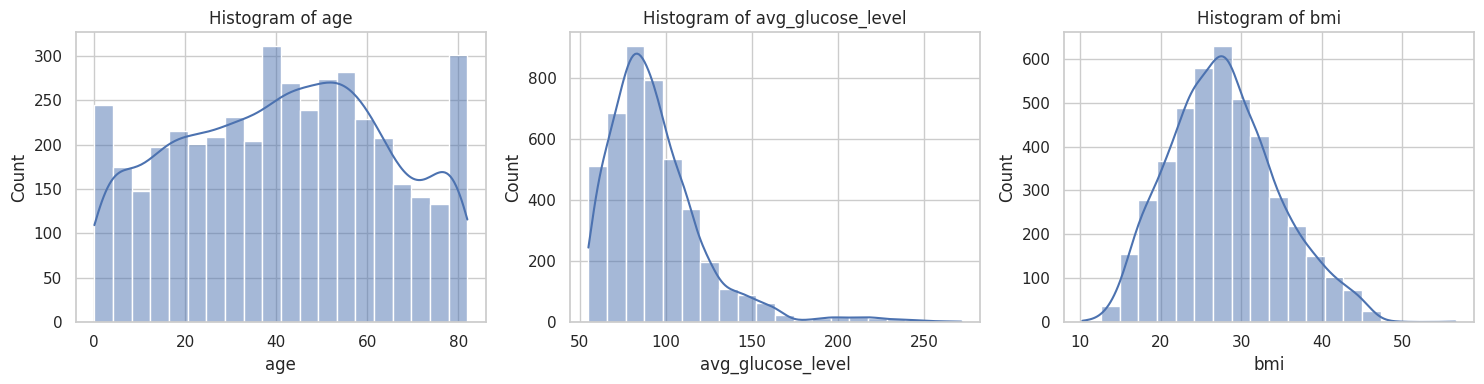

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numeric columns to check
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

# Boxplots
plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Histograms
plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df_clean[col], bins=20, kde=True)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


## Correlation matrix

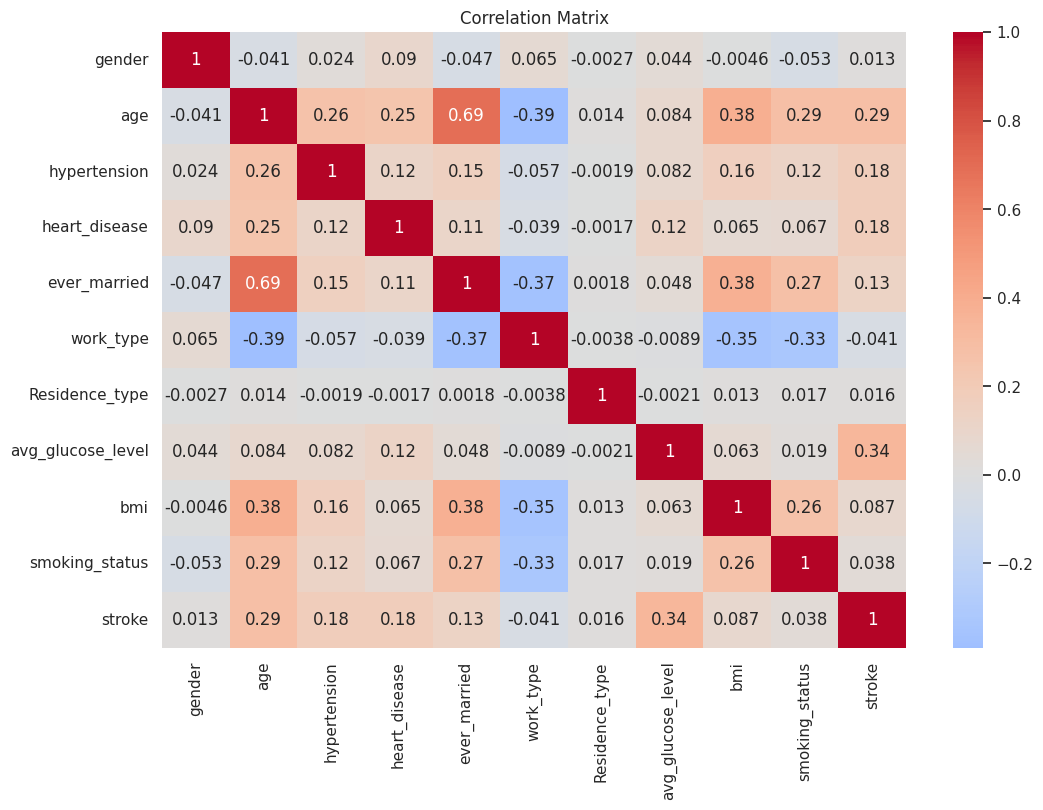

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables for correlation
encoded_data = df_clean.copy()
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()
for col in categorical_cols:
    encoded_data[col] = le.fit_transform(encoded_data[col])

plt.figure(figsize=(12, 8))
sns.heatmap(encoded_data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
stroke_percent = df_clean['stroke'].value_counts(normalize=True) * 100
print(stroke_percent)


stroke
0    94.298145
1     5.701855
Name: proportion, dtype: float64


#  Data Cleaning and Preprocessing

## encoding dataset

In [68]:
from sklearn.preprocessing import LabelEncoder

df_oh = df_clean.copy()

le = LabelEncoder()
df_oh['ever_married'] = le.fit_transform(df_oh['ever_married'])
df_oh['Residence_type'] = le.fit_transform(df_oh['Residence_type'])

# One-hot encoding
df_oh = pd.get_dummies(df_oh, columns=['gender', 'work_type', 'smoking_status'] , dtype=int)
# Verify
print(df_oh.columns)
df_oh.head()

Index(['age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Female',
       'gender_Male', 'gender_Other', 'work_type_Govt_job',
       'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children',
       'smoking_status_Unknown', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='object')


,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,1,228.69,36.60,1,0,1,0,0,0,1,0,0,0,1,0,0
1,61.0,0,0,1,0,202.21,31.14,1,1,0,0,0,0,0,1,0,0,0,1,0
2,80.0,0,1,1,0,105.92,32.50,1,0,1,0,0,0,1,0,0,0,0,1,0
3,49.0,0,0,1,1,171.23,34.40,1,1,0,0,0,0,1,0,0,0,0,0,1
4,79.0,1,0,1,0,174.12,24.00,1,1,0,0,0,0,0,1,0,0,0,1,0


### Correlation matrix after encoding

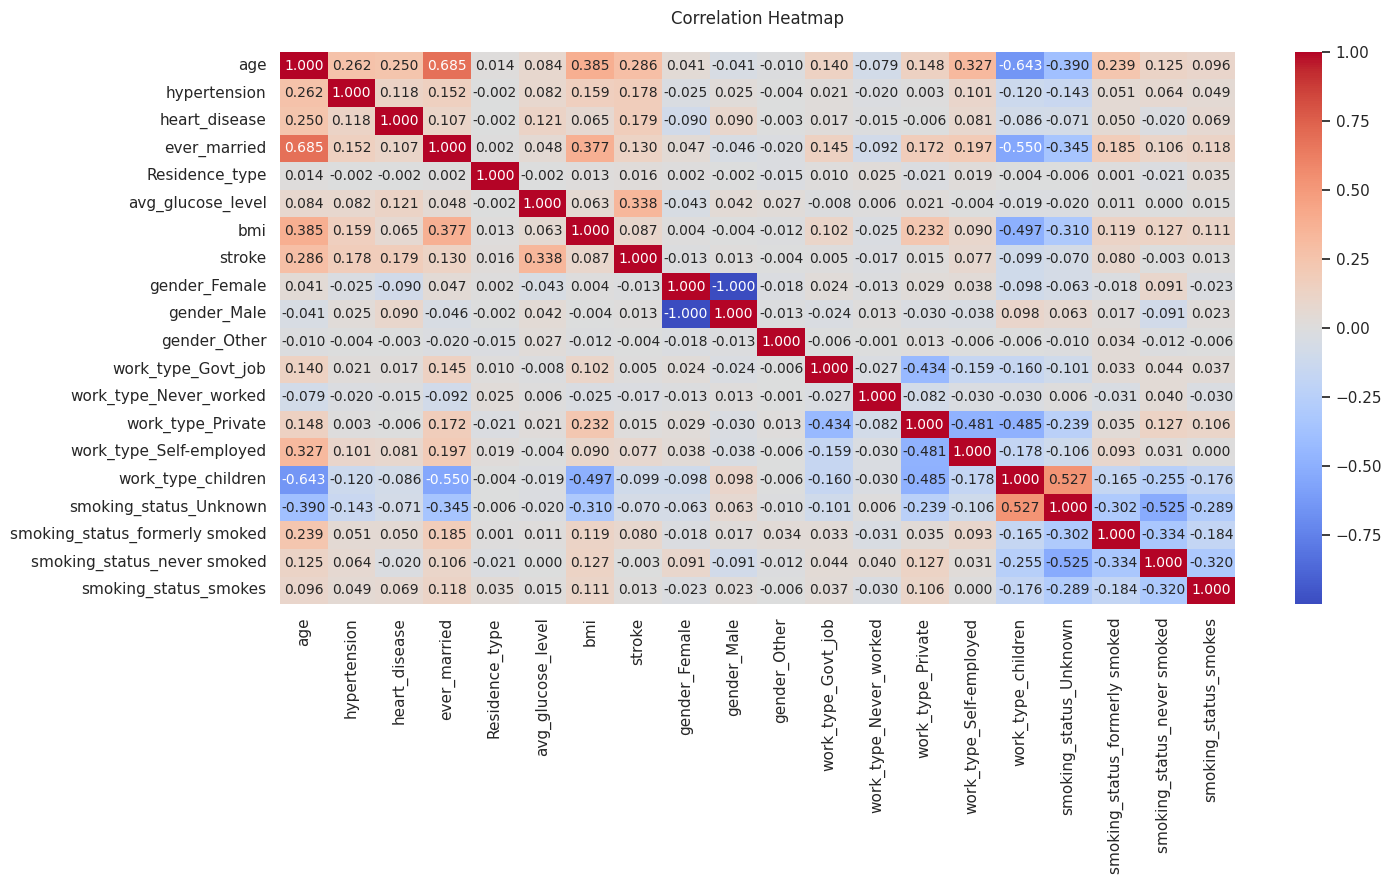

In [ ]:
# Drop non-numerical columns for correlation heatmap
num_df = df_oh.select_dtypes(include=[np.number])

# Correlation matrix
corr = num_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(15, 9))

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f",
            annot_kws={"size": 10})
plt.title("Correlation Heatmap", pad=20)
plt.tight_layout()
plt.show()

# Models with no hyper parameter tuning

## Data splitting

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_oh.drop('stroke', axis=1)
y = df_oh['stroke']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)  # 0.1765 * 85% ≈ 15%

# Show the size of each set
print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))


Train set: 3133 samples
Validation set: 672 samples
Test set: 672 samples

Class distribution in training set:
stroke
0    0.944143
1    0.055857
Name: proportion, dtype: float64


## Naïve Bayes no hyper parameter tuning

=== Naïve Bayes Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.42      0.59       635
           1       0.09      0.97      0.16        37

    accuracy                           0.45       672
   macro avg       0.54      0.70      0.38       672
weighted avg       0.95      0.45      0.56       672



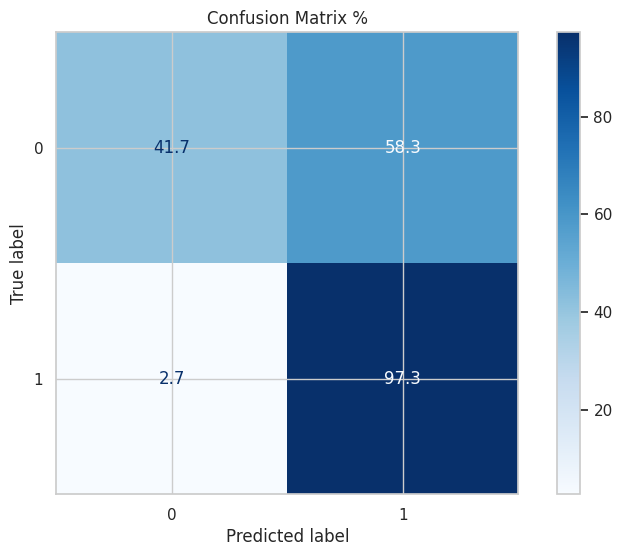

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train the model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_nb = nb_model.predict(X_val)

# Evaluate
print("=== Naïve Bayes Classification Report ===")
print(classification_report(y_val, y_val_pred_nb))

# Confusion Matrix in percentage
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
cm_nb_percentage = cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis] * 100

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb_percentage,
                                display_labels=nb_model.classes_)
disp_nb.plot(cmap='Blues', values_format='.1f')
plt.title("Confusion Matrix %")
plt.show()

## SVM no hyper parameter tuning

=== SVM Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.83      0.90       635
           1       0.18      0.62      0.28        37

    accuracy                           0.82       672
   macro avg       0.58      0.73      0.59       672
weighted avg       0.93      0.82      0.86       672



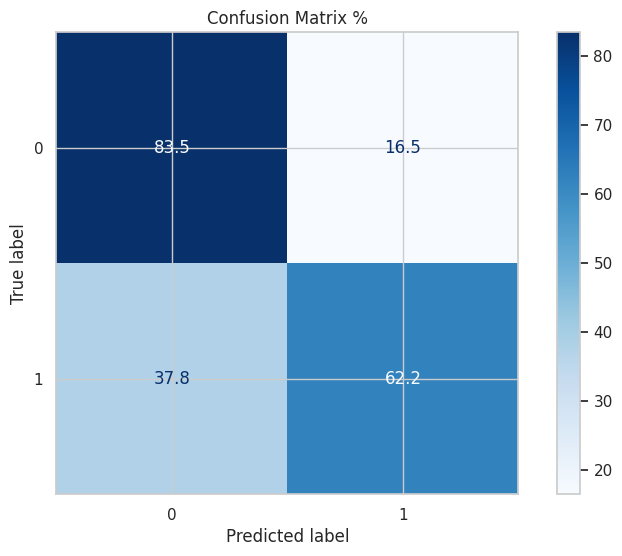

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Build the pipeline
svm_pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced', random_state=42))

# Train the model
svm_pipeline.fit(X_train, y_train)

y_val_pred_nb = svm_pipeline.predict(X_val)

# Predict on validation set
y_pred_svm = svm_pipeline.predict(X_val)

# Evaluate
print("=== SVM Classification Report ===")
print(classification_report(y_val, y_val_pred_nb))

# Confusion Matrix in percentage
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
cm_nb_percentage = cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis] * 100

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb_percentage,
                                display_labels=svm_pipeline.classes_)
disp_nb.plot(cmap='Blues', values_format='.1f')
plt.title("Confusion Matrix %")
plt.show()


# Models with hyper parameter tuning

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Set a consistent style for plots
sns.set_theme(style="whitegrid")


In [70]:

X = df_oh.drop('stroke', axis=1)
y = df_oh['stroke']


In [71]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [72]:
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
print(f"Training Set: {X_train.shape}, Validation Set: {X_val.shape}, Testing Set: {X_test.shape}")

Training Set: (2685, 19), Validation Set: (896, 19), Testing Set: (896, 19)


## Naïve Bayes with hyper parameter tuning

###  grid search

In [75]:
nb_model = GaussianNB()

# Define hyperparameter configurations
param_grid = {
    'var_smoothing': np.logspace(-10, 10, 200)
}

# Perform grid search for hyperparameter tuning
grid_search = GridSearchCV(nb_model, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': array([1.00000000e-10, 1.26038293e-10, 1.58856513e-10, 2.00220037e-10,
       2.52353917e-10, 3.18062569e-10, 4.00880633e-10, 5.05263107e-10,
       6.36824994e-10, 8.02643352e-10, 1.01163798e-09, 1.27505124e-09,
       1.60705282e-09, 2.02550194e-09, 2.55290807e-09, 3.21764175e-09,
       4.05546074e-09, 5.11143348e-09, 6.44...
       4.88025158e+07, 6.15098579e+07, 7.75259749e+07, 9.77124154e+07,
       1.23155060e+08, 1.55222536e+08, 1.95639834e+08, 2.46581108e+08,
       3.10786619e+08, 3.91710149e+08, 4.93704785e+08, 6.22257084e+08,
       7.84282206e+08, 9.88495905e+08, 1.24588336e+09, 1.57029012e+09,
       1.97916687e+09, 2.49450814e+09, 3.14403547e+09, 3.96268864e+09,
       4.99450512e+09, 6.29498899e+09, 7.93409667e+09, 1.00000000e+10])},
             scoring='accuracy', verbose=1)

In [ ]:
best_params = grid_search.best_params_
train_accuracy = grid_search.best_score_
val_accuracy = grid_search.score(X_val, y_val)

In [ ]:
print(f"Best Parameters: {best_params}")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")

Best Parameters: {'var_smoothing': np.float64(1.122667773510816)}
Training Accuracy: 0.95
Validation Accuracy: 0.94


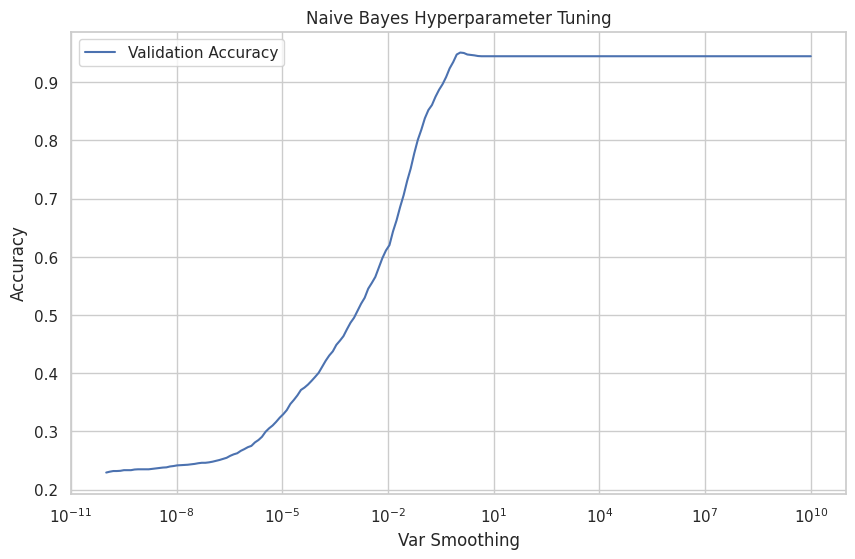

Min: 1e-10 Max: 10000000000.0


In [ ]:
results = pd.DataFrame(grid_search.cv_results_)
# Convert to float explicitly
x_vals = results['param_var_smoothing'].astype(float)
y_vals = results['mean_test_score']

plt.plot(x_vals, y_vals, label="Validation Accuracy")
plt.xscale('log')
plt.xlabel('Var Smoothing')
plt.ylabel('Accuracy')
plt.title('Naive Bayes Hyperparameter Tuning')
plt.legend()
plt.show()
print("Min:", x_vals.min(), "Max:", x_vals.max())


In [ ]:

y_test_pred = grid_search.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

In [ ]:
print(f"Test Set Metrics:")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Test Set Metrics:
Precision: 0.93
Recall: 0.94
F1-Score: 0.93


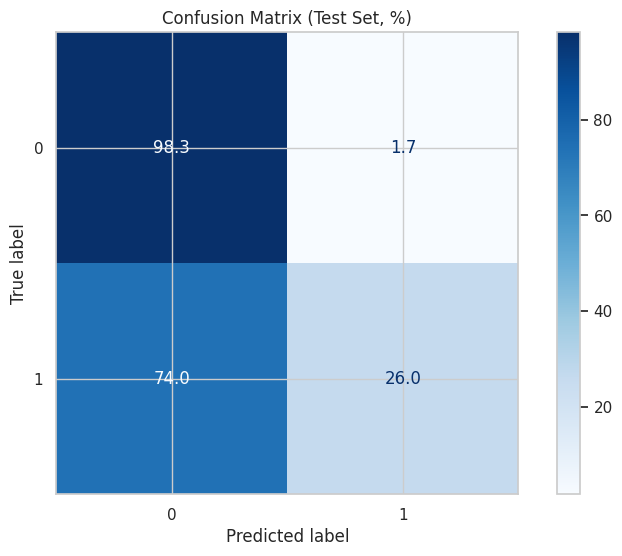

In [ ]:
cm_percent = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=grid_search.classes_)
disp.plot(cmap='Blues', values_format=".1f")  # Show percentages with 1 decimal
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

In [ ]:
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       846
           1       0.48      0.26      0.34        50

    accuracy                           0.94       896
   macro avg       0.72      0.62      0.65       896
weighted avg       0.93      0.94      0.93       896



accuracy is much better than base model

### optuna search

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 6.1 MB/s eta 0:00:00


In [ ]:
!pip install optuna-integration[sklearn]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 kB 1.6 MB/s eta 0:00:00


In [ ]:
nb_model = GaussianNB()

param_distributions = {
    'var_smoothing': FloatDistribution(1e-10, 1e10, log=True)
}

In [ ]:
optuna_search = OptunaSearchCV(
    nb_model,
    param_distributions,
    cv=5,
    n_trials=1000,
    random_state=42,
    scoring='accuracy',
    verbose=1,
    refit=True
)

<ipython-input-115-168b41ce88a6>:1: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


In [ ]:
optuna_search.fit(X_train, y_train)


[I 2025-05-01 18:42:35,641] A new study created in memory with name: no-name-0aa44348-3462-48e7-ac7b-20d165c256e4
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 2685 samples...
[I 2025-05-01 18:42:35,722] Trial 0 finished with value: 0.8454376163873369 and parameters: {'var_smoothing': 0.12417124752806454}. Best is trial 0 with value: 0.8454376163873369.
[I 2025-05-01 18:42:35,793] Trial 1 finished with value: 0.9445065176908752 and parameters: {'var_smoothing': 4494078.418680508}. Best is trial 1 with value: 0.9445065176908752.
[I 2025-05-01 18:42:35,874] Trial 2 finished with value: 0.23575418994413408 and parameters: {'var_smoothing': 2.4045112728192066e-09}. Best is trial 1 with value: 0.9445065176908752.
[I 2025-05-01 18:42:35,954] Trial 3 finished with value: 0.4338919925512104 and parameters: {'var_smoothing': 0.0002448753224028848}. Best is trial 1 with value: 0.9445065176908752.
[I 2025-05-01 18:42:36,028] Trial 4 finished with value: 0.918063

OptunaSearchCV(cv=5, estimator=GaussianNB(), n_jobs=1, n_trials=1000,
               param_distributions={'var_smoothing': FloatDistribution(high=10000000000.0, log=True, low=1e-10, step=None)},
               random_state=42, scoring='accuracy', verbose=1)

In [ ]:
best_params = optuna_search.best_params_
train_accuracy = optuna_search.best_score_
val_accuracy = optuna_search.score(X_val, y_val)

In [ ]:
print(f"\nBest Parameters: {best_params}")
print(f"Training Accuracy (CV avg): {train_accuracy:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")



Best Parameters: {'var_smoothing': 1.207144541806426}
Training Accuracy (CV avg): 0.95
Validation Accuracy: 0.95


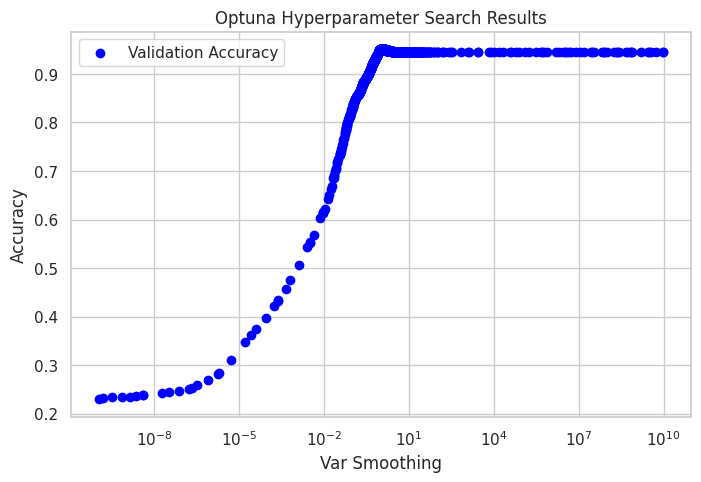

In [ ]:
# 6. Plotting search results
# Manually collect trials
study = optuna_search.study_
trial_params = [trial.params['var_smoothing'] for trial in study.trials]
trial_scores = [trial.value for trial in study.trials]

plt.figure(figsize=(8, 5))
plt.scatter(trial_params, trial_scores, color='blue', label='Validation Accuracy')
plt.xscale('log')
plt.xlabel('Var Smoothing')
plt.ylabel('Accuracy')
plt.title('Optuna Hyperparameter Search Results')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_test_pred = optuna_search.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

print(f"\nTest Set Metrics:")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Test Set Metrics:
Precision: 0.94
Recall: 0.95
F1-Score: 0.94


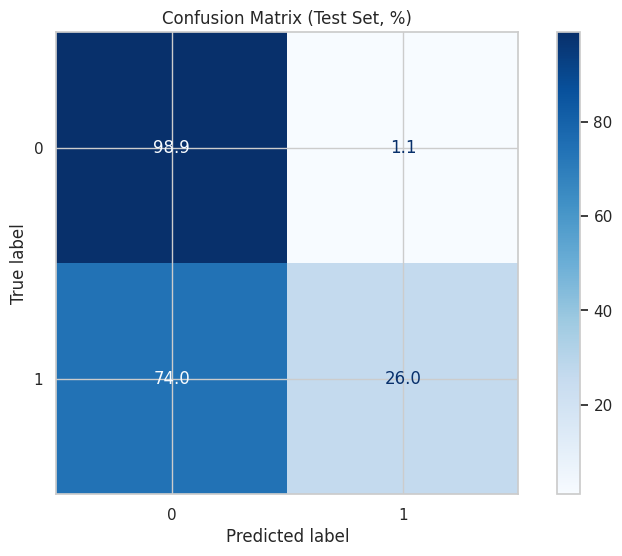

In [ ]:
cm_percent = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=optuna_search.classes_)
disp.plot(cmap='Blues', values_format=".1f")
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

In [ ]:
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       846
           1       0.59      0.26      0.36        50

    accuracy                           0.95       896
   macro avg       0.77      0.62      0.67       896
weighted avg       0.94      0.95      0.94       896



accracy is much better than base model but grid search is better overall

## SVM with hyper parameter tuning

### grid search

In [ ]:
svm_model = SVC(probability=True, random_state=42)


In [ ]:

param_grid_svm = {
    'C': np.logspace(-10, 10, 50),
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf','poly'],
    'class_weight': ['balanced']
}

In [ ]:
grid_search_svm = GridSearchCV(svm_model, param_grid_svm, cv=5, scoring='accuracy', verbose=1)
grid_search_svm.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42),
             param_grid={'C': array([1.00000000e-10, 2.55954792e-10, 6.55128557e-10, 1.67683294e-09,
       4.29193426e-09, 1.09854114e-08, 2.81176870e-08, 7.19685673e-08,
       1.84206997e-07, 4.71486636e-07, 1.20679264e-06, 3.08884360e-06,
       7.90604321e-06, 2.02358965e-05, 5.17947468e-05, 1.32571137e-04,
       3.39322177e-04, 8.6851...
       1.15139540e+03, 2.94705170e+03, 7.54312006e+03, 1.93069773e+04,
       4.94171336e+04, 1.26485522e+05, 3.23745754e+05, 8.28642773e+05,
       2.12095089e+06, 5.42867544e+06, 1.38949549e+07, 3.55648031e+07,
       9.10298178e+07, 2.32995181e+08, 5.96362332e+08, 1.52641797e+09,
       3.90693994e+09, 1.00000000e+10]),
                         'class_weight': ['balanced'],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['rbf', 'poly']},
             scoring='accuracy', verbose=1)

In [ ]:
best_params_grid = grid_search_svm.best_params_
train_accuracy_grid = grid_search_svm.best_score_
val_accuracy_grid = grid_search_svm.score(X_val, y_val)

In [ ]:
print("\n=== SVM GridSearch Results ===")
print(f"Best Parameters: {best_params_grid}")
print(f"Training Accuracy: {train_accuracy_grid:.2f}")
print(f"Validation Accuracy: {val_accuracy_grid:.2f}")


=== SVM GridSearch Results ===
Best Parameters: {'C': np.float64(0.0022229964825261957), 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'poly'}
Training Accuracy: 0.96
Validation Accuracy: 0.95


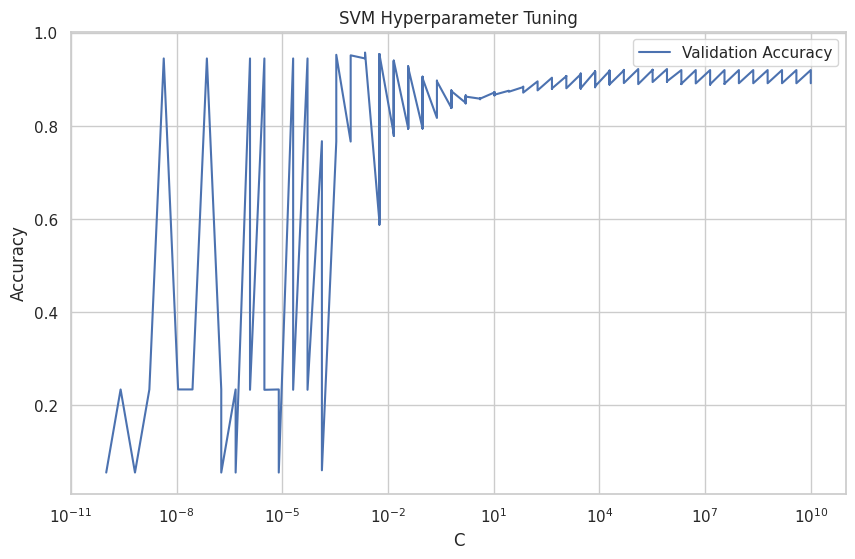

In [ ]:
results = pd.DataFrame(grid_search_svm.cv_results_)
# Access the correct parameter name based on the param_grid_svm used
plt.plot(results['param_C'], results['mean_test_score'], label="Validation Accuracy")
plt.xscale('log')
plt.xlabel('C')  # Update x-axis label
plt.ylabel('Accuracy')
plt.title('SVM Hyperparameter Tuning')
plt.legend()
plt.show()


Test Set Metrics (GridSearch):
Precision: 0.95
Recall: 0.95
F1-Score: 0.94


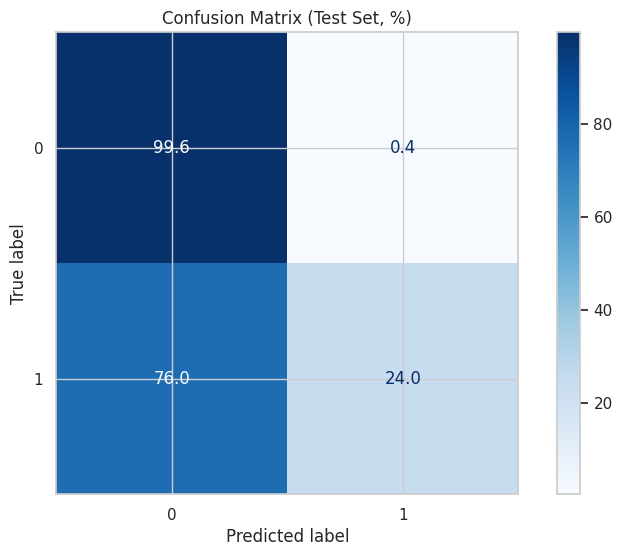


Classification Report (Test Set - GridSearch):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       846
           1       0.80      0.24      0.37        50

    accuracy                           0.95       896
   macro avg       0.88      0.62      0.67       896
weighted avg       0.95      0.95      0.94       896



In [ ]:
y_test_pred_grid = grid_search_svm.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred_grid, average='weighted')
conf_matrix_test = confusion_matrix(y_test, y_test_pred_grid)

print(f"\nTest Set Metrics (GridSearch):")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

cm_percent = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=grid_search_svm.classes_)
disp.plot(cmap='Blues', values_format=".1f")
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

print("\nClassification Report (Test Set - GridSearch):")
print(classification_report(y_test, y_test_pred_grid))

accuracy better than base model

### optuna search

In [ ]:
optuna_search_svm = OptunaSearchCV(
    svm_model,
    {
        'C': optuna.distributions.FloatDistribution(1e-10, 1e10, log=True),
        'gamma': optuna.distributions.FloatDistribution(1e-4, 1e1, log=True),
        'kernel': optuna.distributions.CategoricalDistribution(['rbf', 'poly']),
        'class_weight': optuna.distributions.CategoricalDistribution(['balanced'])
    },
    n_trials=1000,
    cv=5,
    scoring='accuracy',
    verbose=1,
    random_state=42
)

<ipython-input-205-4f73c0275022>:1: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search_svm = OptunaSearchCV(


2 fold validation less reliable but for the sake of saving time

In [ ]:
optuna_search_svm.fit(X_train, y_train)


[I 2025-05-01 19:17:11,301] A new study created in memory with name: no-name-0eca6e16-4695-4895-8270-dd1ca4143ad0
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 2685 samples...
[I 2025-05-01 19:17:17,506] Trial 0 finished with value: 0.8785847299813779 and parameters: {'C': 0.12417124752806454, 'gamma': 1.4559959319972098, 'kernel': 'poly', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8785847299813779.
[I 2025-05-01 19:17:23,080] Trial 1 finished with value: 0.8007448789571695 and parameters: {'C': 0.5055264220344518, 'gamma': 0.0030996178756476853, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8785847299813779.
[I 2025-05-01 19:17:27,604] Trial 2 finished with value: 0.055493482309124764 and parameters: {'C': 3.34523114941389e-07, 'gamma': 0.003914949966612523, 'kernel': 'poly', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8785847299813779.
[I 2025-05-01 19:17:32,161] Trial 3 finished with valu

OptunaSearchCV(cv=5, estimator=SVC(probability=True, random_state=42), n_jobs=1,
               n_trials=1000,
               param_distributions={'C': FloatDistribution(high=10000000000.0, log=True, low=1e-10, step=None),
                                    'class_weight': CategoricalDistribution(choices=('balanced',)),
                                    'gamma': FloatDistribution(high=10.0, log=True, low=0.0001, step=None),
                                    'kernel': CategoricalDistribution(choices=('rbf', 'poly'))},
               random_state=42, scoring='accuracy', verbose=1)

In [ ]:
best_params_optuna = optuna_search_svm.best_params_
train_accuracy_optuna = optuna_search_svm.best_score_
val_accuracy_optuna = optuna_search_svm.score(X_val, y_val)

In [ ]:
print("\n=== SVM OptunaSearch Results ===")
print(f"Best Parameters: {best_params_optuna}")
print(f"Training Accuracy: {train_accuracy_optuna:.2f}")
print(f"Validation Accuracy: {val_accuracy_optuna:.2f}")


=== SVM OptunaSearch Results ===
Best Parameters: {'C': 1.055820014841704e-07, 'gamma': 1.489784070472556, 'kernel': 'poly', 'class_weight': 'balanced'}
Training Accuracy: 0.96
Validation Accuracy: 0.95


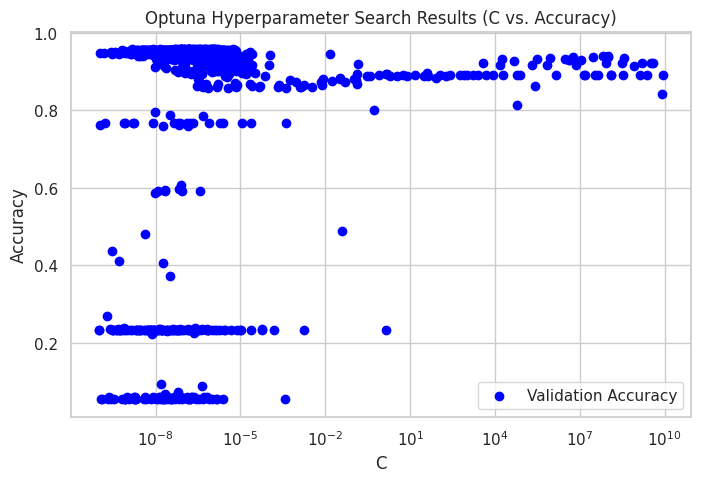

In [ ]:
# 6. Plotting search results
# Manually collect trials
study = optuna_search_svm.study_

# Access the correct parameters based on your SVM model
trial_params_C = [trial.params['C'] for trial in study.trials]
trial_params_gamma = [trial.params['gamma'] for trial in study.trials]
trial_scores = [trial.value for trial in study.trials]

# Example: Plot C vs. Accuracy
plt.figure(figsize=(8, 5))
plt.scatter(trial_params_C, trial_scores, color='blue', label='Validation Accuracy')
plt.xscale('log')
plt.xlabel('C')  # X-axis label for C
plt.ylabel('Accuracy')
plt.title('Optuna Hyperparameter Search Results (C vs. Accuracy)')
plt.legend()
plt.grid(True)
plt.show()

# You can similarly plot for 'gamma' or other hyperparameters


Test Set Metrics (OptunaSearch):
Precision: 0.95
Recall: 0.95
F1-Score: 0.94


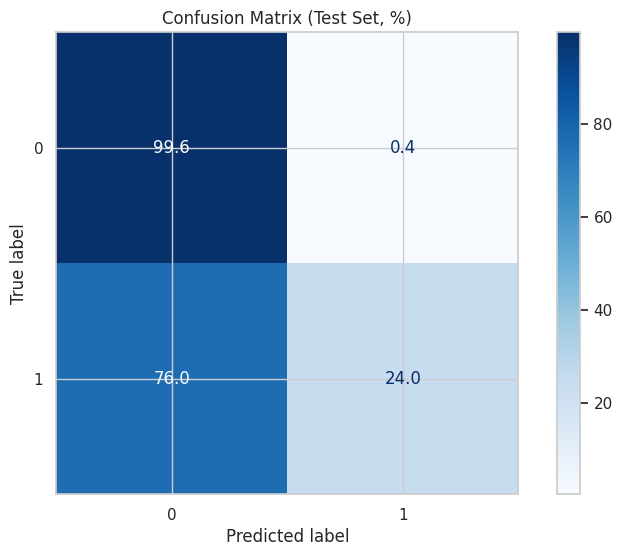


Classification Report (Test Set - OptunaSearch):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       846
           1       0.80      0.24      0.37        50

    accuracy                           0.95       896
   macro avg       0.88      0.62      0.67       896
weighted avg       0.95      0.95      0.94       896



In [ ]:
y_test_pred_optuna = optuna_search_svm.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred_optuna, average='weighted')
conf_matrix_test_optuna = confusion_matrix(y_test, y_test_pred_optuna)

print(f"\nTest Set Metrics (OptunaSearch):")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

cm_percent = conf_matrix_test_optuna.astype('float') / conf_matrix_test_optuna.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=optuna_search_svm.classes_)
disp.plot(cmap='Blues', values_format=".1f")
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

print("\nClassification Report (Test Set - OptunaSearch):")
print(classification_report(y_test, y_test_pred_optuna))

accuracy better than base model and grid search

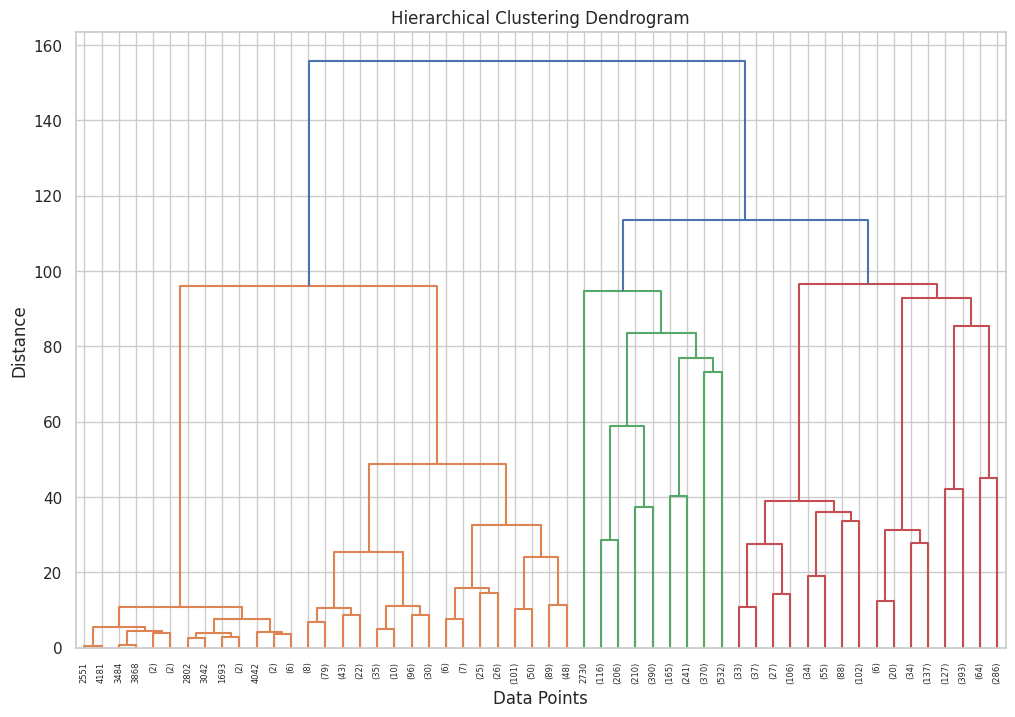

In [ ]:
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

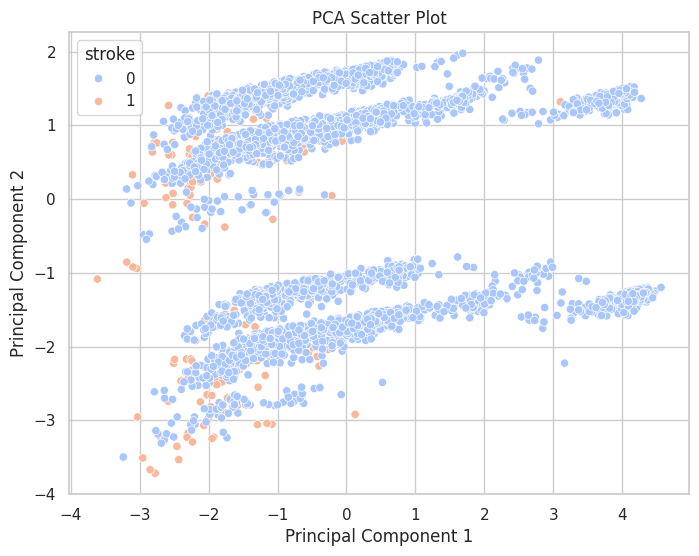

In [ ]:
# --- 9. PCA Visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm')
plt.title("PCA Scatter Plot")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Feature reduction

Residence_type: Shows very low correlations with all other variables, indicating it likely has little to no impact on the target or other features.

gender_Female and gender_Male: These are perfectly correlated (1.000), which means they are redundant. Only one gender variable should be kept (e.g., "gender_Male" as a binary indicator, with "gender_Female" implied when "gender_Male" is 0).

gender_Other: Shows negligible correlations with all other variables, suggesting it may not be informative for the model.

work_type_Never_worked: Has very low correlations with other variables and might represent a very small subset of the data, making it less useful for generalization.

Consider removing ever_married or work_type_children if age is kept, due to their high correlation with age.

## encoding dataset

In [43]:
from sklearn.preprocessing import LabelEncoder

df_oh = df_clean.copy()

le = LabelEncoder()
df_oh['ever_married'] = le.fit_transform(df_oh['ever_married'])
df_oh['Residence_type'] = le.fit_transform(df_oh['Residence_type'])

# One-hot encoding
df_oh = pd.get_dummies(df_oh, columns=['gender', 'work_type', 'smoking_status'] , dtype=int)

print(df_oh.columns)
df_oh.head()

Index(['age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Female',
       'gender_Male', 'gender_Other', 'work_type_Govt_job',
       'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children',
       'smoking_status_Unknown', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='object')


,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,1,228.69,36.60,1,0,1,0,0,0,1,0,0,0,1,0,0
1,61.0,0,0,1,0,202.21,31.14,1,1,0,0,0,0,0,1,0,0,0,1,0
2,80.0,0,1,1,0,105.92,32.50,1,0,1,0,0,0,1,0,0,0,0,1,0
3,49.0,0,0,1,1,171.23,34.40,1,1,0,0,0,0,1,0,0,0,0,0,1
4,79.0,1,0,1,0,174.12,24.00,1,1,0,0,0,0,0,1,0,0,0,1,0


In [44]:
df_oh.drop(['Residence_type'], axis=1, inplace=True)

In [45]:
df_oh.drop(['gender_Other', 'gender_Female'], axis=1, inplace=True)

In [46]:
df_oh.drop(['work_type_Never_worked'], axis=1, inplace=True)

In [47]:
df_oh.drop(['work_type_children'], axis=1, inplace=True)

In [48]:
df_oh.drop(['ever_married'], axis=1, inplace=True)

In [49]:
df_oh.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,work_type_Govt_job,work_type_Private,work_type_Self-employed,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.60,1,1,0,1,0,0,1,0,0
1,61.0,0,0,202.21,31.14,1,0,0,0,1,0,0,1,0
2,80.0,0,1,105.92,32.50,1,1,0,1,0,0,0,1,0
3,49.0,0,0,171.23,34.40,1,0,0,1,0,0,0,0,1
4,79.0,1,0,174.12,24.00,1,0,0,0,1,0,0,1,0


# Models with no hyper parameter tuning

## Data splitting

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_oh.drop('stroke', axis=1)
y = df_oh['stroke']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)  # 0.1765 * 85% ≈ 15%

print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))


Train set: 3133 samples
Validation set: 672 samples
Test set: 672 samples

Class distribution in training set:
stroke
0    0.944143
1    0.055857
Name: proportion, dtype: float64


## Naïve Bayes no hyper parameter tuning

=== Naïve Bayes Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       635
           1       0.24      0.49      0.32        37

    accuracy                           0.89       672
   macro avg       0.61      0.70      0.63       672
weighted avg       0.93      0.89      0.91       672



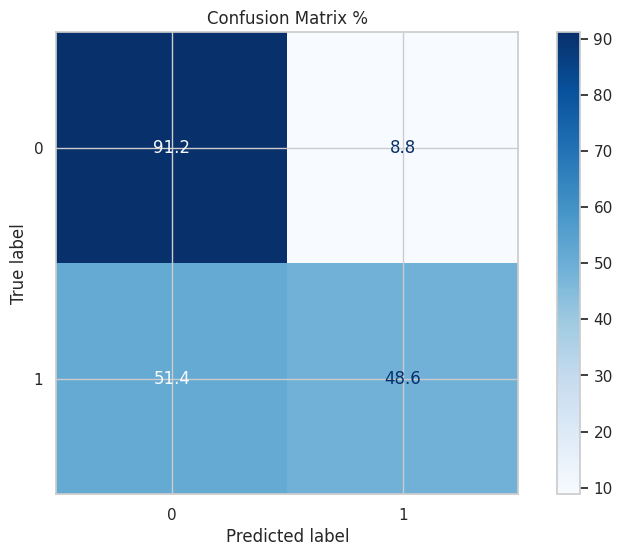

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train the model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_nb = nb_model.predict(X_val)

# Evaluate
print("=== Naïve Bayes Classification Report ===")
print(classification_report(y_val, y_val_pred_nb))

# Confusion Matrix in percentage
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
cm_nb_percentage = cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis] * 100

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb_percentage,
                                display_labels=nb_model.classes_)
disp_nb.plot(cmap='Blues', values_format='.1f')
plt.title("Confusion Matrix %")
plt.show()

model accuracy greatly increased after feature reduction

## SVM no hyper parameter tuning

=== SVM Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.83      0.90       635
           1       0.17      0.59      0.27        37

    accuracy                           0.82       672
   macro avg       0.57      0.71      0.58       672
weighted avg       0.93      0.82      0.86       672



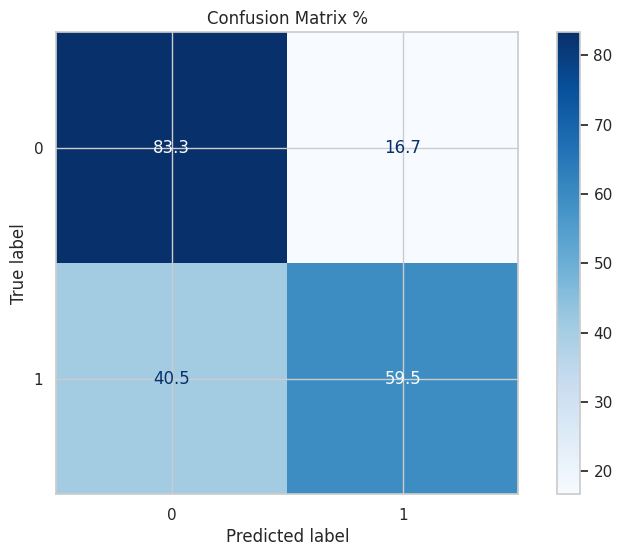

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Build the pipeline
svm_pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced', random_state=42))

# Train the model
svm_pipeline.fit(X_train, y_train)

y_val_pred_nb = svm_pipeline.predict(X_val)

# Predict on validation set
y_pred_svm = svm_pipeline.predict(X_val)

# Evaluate
print("=== SVM Classification Report ===")
print(classification_report(y_val, y_val_pred_nb))

# Confusion Matrix in percentage
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
cm_nb_percentage = cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis] * 100

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb_percentage,
                                display_labels=svm_pipeline.classes_)
disp_nb.plot(cmap='Blues', values_format='.1f')
plt.title("Confusion Matrix %")
plt.show()


model benifited from feature reduction and accuracy increased by 0.01

# Models with hyper parameter tuning

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Set a consistent style for plots
sns.set_theme(style="whitegrid")


In [51]:

X = df_oh.drop('stroke', axis=1)
y = df_oh['stroke']


In [52]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [53]:
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
print(f"Training Set: {X_train.shape}, Validation Set: {X_val.shape}, Testing Set: {X_test.shape}")

Training Set: (2685, 13), Validation Set: (896, 13), Testing Set: (896, 13)


## Naïve Bayes with hyper parameter tuning

###  grid search

In [ ]:
nb_model = GaussianNB()

# Define hyperparameter configurations
param_grid = {
    'var_smoothing': np.logspace(-10, 10, 200)
}

# Perform grid search for hyperparameter tuning
grid_search = GridSearchCV(nb_model, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': array([1.00000000e-10, 1.26038293e-10, 1.58856513e-10, 2.00220037e-10,
       2.52353917e-10, 3.18062569e-10, 4.00880633e-10, 5.05263107e-10,
       6.36824994e-10, 8.02643352e-10, 1.01163798e-09, 1.27505124e-09,
       1.60705282e-09, 2.02550194e-09, 2.55290807e-09, 3.21764175e-09,
       4.05546074e-09, 5.11143348e-09, 6.44...
       4.88025158e+07, 6.15098579e+07, 7.75259749e+07, 9.77124154e+07,
       1.23155060e+08, 1.55222536e+08, 1.95639834e+08, 2.46581108e+08,
       3.10786619e+08, 3.91710149e+08, 4.93704785e+08, 6.22257084e+08,
       7.84282206e+08, 9.88495905e+08, 1.24588336e+09, 1.57029012e+09,
       1.97916687e+09, 2.49450814e+09, 3.14403547e+09, 3.96268864e+09,
       4.99450512e+09, 6.29498899e+09, 7.93409667e+09, 1.00000000e+10])},
             scoring='accuracy', verbose=1)

In [ ]:
best_params = grid_search.best_params_
train_accuracy = grid_search.best_score_
val_accuracy = grid_search.score(X_val, y_val)

In [ ]:
print(f"Best Parameters: {best_params}")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")

Best Parameters: {'var_smoothing': np.float64(1.783430876931913)}
Training Accuracy: 0.95
Validation Accuracy: 0.95


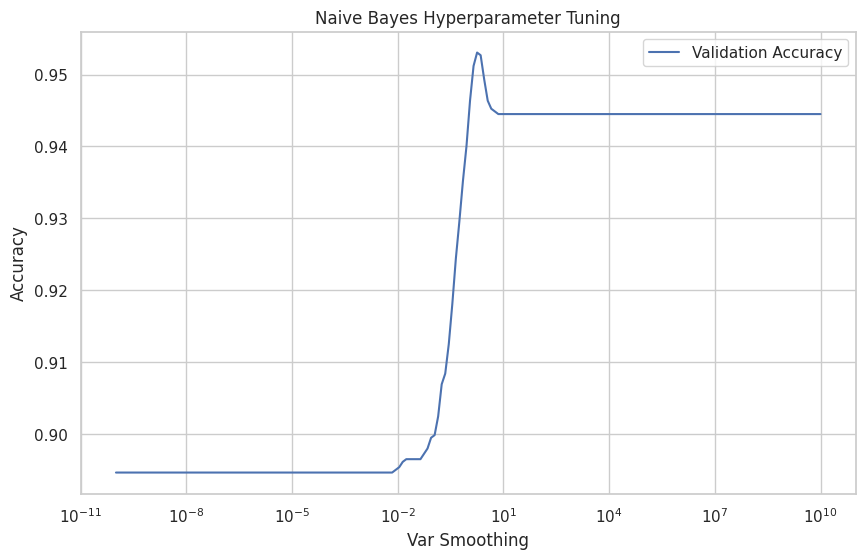

In [ ]:
results = pd.DataFrame(grid_search.cv_results_)
plt.plot(results['param_var_smoothing'], results['mean_test_score'], label="Validation Accuracy")
plt.xscale('log')
plt.xlabel('Var Smoothing')
plt.ylabel('Accuracy')
plt.title('Naive Bayes Hyperparameter Tuning')
plt.legend()
plt.show()

In [ ]:

y_test_pred = grid_search.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

In [ ]:
print(f"Test Set Metrics:")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Test Set Metrics:
Precision: 0.94
Recall: 0.95
F1-Score: 0.94


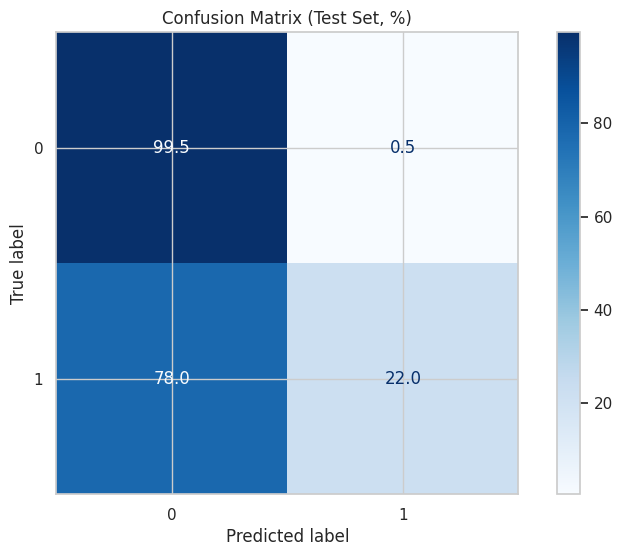

In [ ]:
cm_percent = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=grid_search.classes_)
disp.plot(cmap='Blues', values_format=".1f")
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

In [ ]:
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       846
           1       0.73      0.22      0.34        50

    accuracy                           0.95       896
   macro avg       0.84      0.61      0.66       896
weighted avg       0.94      0.95      0.94       896



model did not benifit from feature reduction and accuracy remained the same

In [ ]:
linkage_matrix = linkage(X_scaled, method='ward')

### optuna search

In [ ]:
!pip install optuna

In [ ]:
!pip install optuna-integration[sklearn]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 kB 2.5 MB/s eta 0:00:00


In [ ]:
nb_model = GaussianNB()

param_distributions = {
    'var_smoothing': FloatDistribution(1e-10, 1e10, log=True)
}

In [ ]:
optuna_search = OptunaSearchCV(
    nb_model,
    param_distributions,
    cv=5,
    n_trials=1000,
    random_state=42,
    scoring='accuracy',
    verbose=1,
    refit=True
)

<ipython-input-241-168b41ce88a6>:1: ExperimentalWarning:

OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.



In [ ]:
optuna_search.fit(X_train, y_train)


[I 2025-05-01 22:57:09,333] A new study created in memory with name: no-name-0551e885-be1e-44b5-9a49-e201b425d9ab
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 2685 samples...
[I 2025-05-01 22:57:09,414] Trial 0 finished with value: 0.9005586592178771 and parameters: {'var_smoothing': 0.12417124752806454}. Best is trial 0 with value: 0.9005586592178771.
[I 2025-05-01 22:57:09,481] Trial 1 finished with value: 0.9445065176908752 and parameters: {'var_smoothing': 4494078.418680508}. Best is trial 1 with value: 0.9445065176908752.
[I 2025-05-01 22:57:09,514] Trial 2 finished with value: 0.8945996275605215 and parameters: {'var_smoothing': 2.4045112728192066e-09}. Best is trial 1 with value: 0.9445065176908752.
[I 2025-05-01 22:57:09,564] Trial 3 finished with value: 0.8945996275605215 and parameters: {'var_smoothing': 0.0002448753224028848}. Best is trial 1 with value: 0.9445065176908752.
[I 2025-05-01 22:57:09,604] Trial 4 finished with value: 0.9284916

OptunaSearchCV(cv=5, estimator=GaussianNB(), n_jobs=1, n_trials=1000,
               param_distributions={'var_smoothing': FloatDistribution(high=10000000000.0, log=True, low=1e-10, step=None)},
               random_state=42, scoring='accuracy', verbose=1)

In [ ]:
best_params = optuna_search.best_params_
train_accuracy = optuna_search.best_score_
val_accuracy = optuna_search.score(X_val, y_val)

In [ ]:
print(f"\nBest Parameters: {best_params}")
print(f"Training Accuracy (CV avg): {train_accuracy:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")



Best Parameters: {'var_smoothing': 2.424605682692119}
Training Accuracy (CV avg): 0.95
Validation Accuracy: 0.95


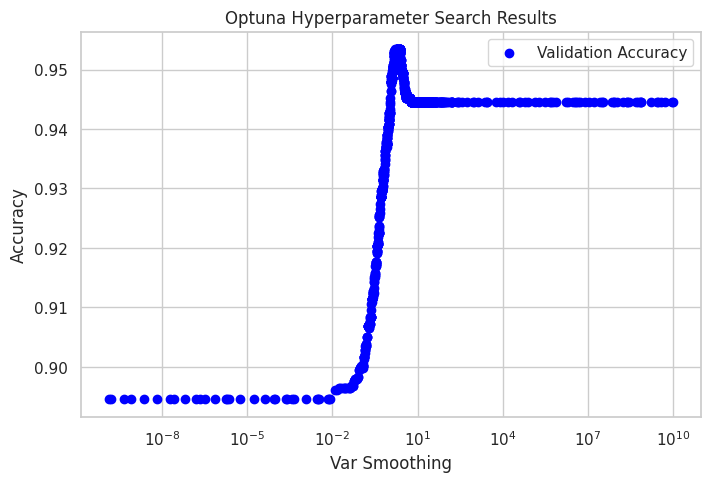

In [ ]:
study = optuna_search.study_
trial_params = [trial.params['var_smoothing'] for trial in study.trials]
trial_scores = [trial.value for trial in study.trials]

plt.figure(figsize=(8, 5))
plt.scatter(trial_params, trial_scores, color='blue', label='Validation Accuracy')
plt.xscale('log')
plt.xlabel('Var Smoothing')
plt.ylabel('Accuracy')
plt.title('Optuna Hyperparameter Search Results')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_test_pred = optuna_search.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

print(f"\nTest Set Metrics:")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Test Set Metrics:
Precision: 0.95
Recall: 0.95
F1-Score: 0.94


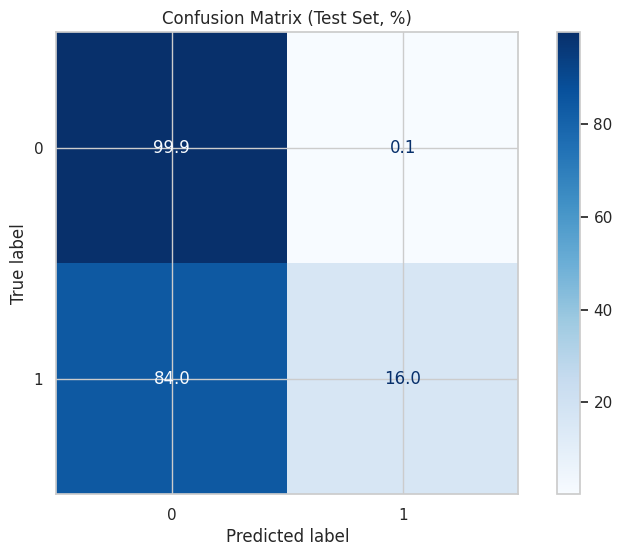

In [ ]:
cm_percent = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=optuna_search.classes_)
disp.plot(cmap='Blues', values_format=".1f")
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

In [ ]:
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       846
           1       0.89      0.16      0.27        50

    accuracy                           0.95       896
   macro avg       0.92      0.58      0.62       896
weighted avg       0.95      0.95      0.94       896



madel benifited from feature reduction but accuracy remained the same

## SVM with hyper parameter tuning

### grid search

In [36]:
svm_model = SVC(probability=True, random_state=42)


In [37]:

param_grid_svm = {
    'C': np.logspace(-10, 10, 125),
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf','poly'],
    'class_weight': ['balanced']
}

less reliable grid search but for the sake of saving time

In [38]:
grid_search_svm = GridSearchCV(svm_model, param_grid_svm, cv=2, scoring='accuracy', verbose=1)
grid_search_svm.fit(X_train, y_train)

Fitting 2 folds for each of 500 candidates, totalling 1000 fits


GridSearchCV(cv=2, estimator=SVC(probability=True, random_state=42),
             param_grid={'C': array([1.00000000e-10, 1.44974067e-10, 2.10174801e-10, 3.04698957e-10,
       4.41734470e-10, 6.40400427e-10, 9.28414545e-10, 1.34596032e-09,
       1.95129342e-09, 2.82886943e-09, 4.10112707e-09, 5.94557071e-09,
       8.61953566e-09, 1.24960914e-08, 1.81160919e-08, 2.62636353e-08,
       3.80754602e-08, 5.5199...
       2.62636353e+07, 3.80754602e+07, 5.51995432e+07, 8.00250228e+07,
       1.16015530e+08, 1.68192432e+08, 2.43835410e+08, 3.53498111e+08,
       5.12480588e+08, 7.42963951e+08, 1.07710506e+09, 1.56152301e+09,
       2.26380341e+09, 3.28192787e+09, 4.75794431e+09, 6.89778538e+09,
       1.00000000e+10]),
                         'class_weight': ['balanced'],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['rbf', 'poly']},
             scoring='accuracy', verbose=1)

In [39]:
best_params_grid = grid_search_svm.best_params_
train_accuracy_grid = grid_search_svm.best_score_
val_accuracy_grid = grid_search_svm.score(X_val, y_val)

In [40]:
print("\n=== SVM GridSearch Results ===")
print(f"Best Parameters: {best_params_grid}")
print(f"Training Accuracy: {train_accuracy_grid:.2f}")
print(f"Validation Accuracy: {val_accuracy_grid:.2f}")


=== SVM GridSearch Results ===
Best Parameters: {'C': np.float64(0.0012496091412919868), 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'poly'}
Training Accuracy: 0.96
Validation Accuracy: 0.95


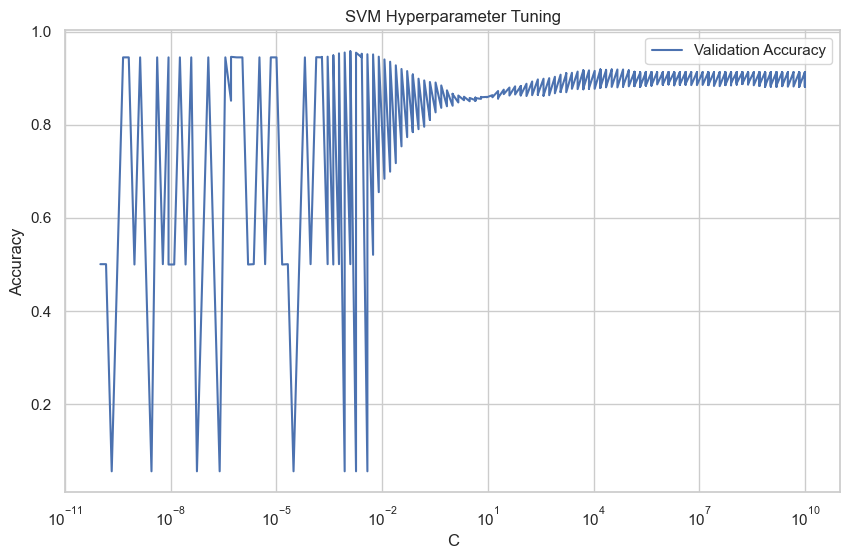

In [41]:
results = pd.DataFrame(grid_search_svm.cv_results_)
# Access the correct parameter name based on the param_grid_svm used
plt.plot(results['param_C'], results['mean_test_score'], label="Validation Accuracy")
plt.xscale('log')
plt.xlabel('C')  # Update x-axis label
plt.ylabel('Accuracy')
plt.title('SVM Hyperparameter Tuning')
plt.legend()
plt.show()


Test Set Metrics (GridSearch):
Precision: 0.95
Recall: 0.95
F1-Score: 0.94


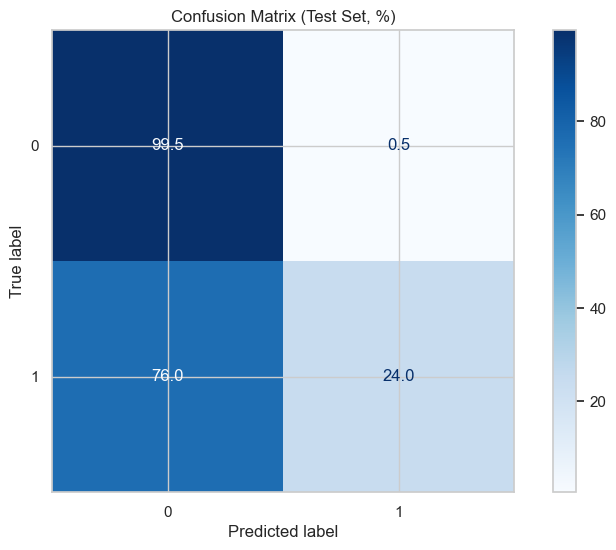


Classification Report (Test Set - GridSearch):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       846
           1       0.75      0.24      0.36        50

    accuracy                           0.95       896
   macro avg       0.85      0.62      0.67       896
weighted avg       0.95      0.95      0.94       896



In [42]:
y_test_pred_grid = grid_search_svm.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred_grid, average='weighted')
conf_matrix_test = confusion_matrix(y_test, y_test_pred_grid)

print(f"\nTest Set Metrics (GridSearch):")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

cm_percent = conf_matrix_test.astype('float') / conf_matrix_test.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=grid_search_svm.classes_)
disp.plot(cmap='Blues', values_format=".1f")
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

print("\nClassification Report (Test Set - GridSearch):")
print(classification_report(y_test, y_test_pred_grid))

model did not benifit from feature reduction and accuracy decreased by 0.02

accuracy better than base model

### optuna search

In [54]:
optuna_search_svm = OptunaSearchCV(
    svm_model,
    {
        'C': optuna.distributions.FloatDistribution(1e-10, 1e10, log=True),
        'gamma': optuna.distributions.FloatDistribution(1e-4, 1e1, log=True),
        'kernel': optuna.distributions.CategoricalDistribution(['rbf', 'poly']),
        'class_weight': optuna.distributions.CategoricalDistribution(['balanced'])
    },
    n_trials=1000,
    cv=2,
    scoring='accuracy',
    verbose=1,
    random_state=42
)

C:\Users\hassa\AppData\Local\Temp\ipykernel_21324\2457660873.py:1: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search_svm = OptunaSearchCV(


for some unknown reason optuna is stuck on the 4th iteration therfore number of n_trials is 4

In [55]:
optuna_search_svm.fit(X_train, y_train)


[I 2025-05-03 20:07:57,574] A new study created in memory with name: no-name-7ce3cf95-4589-4361-b1f2-73280a5bc630
[I 2025-05-03 20:07:58,025] Trial 0 finished with value: 0.8688957369059416 and parameters: {'C': 0.12417124752806454, 'gamma': 1.4559959319972098, 'kernel': 'poly', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8688957369059416.
[I 2025-05-03 20:07:58,483] Trial 1 finished with value: 0.8256860932605229 and parameters: {'C': 0.5055264220344518, 'gamma': 0.0030996178756476853, 'kernel': 'rbf', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8688957369059416.
[I 2025-05-03 20:07:58,836] Trial 2 finished with value: 0.49964822843623674 and parameters: {'C': 3.34523114941389e-07, 'gamma': 0.003914949966612523, 'kernel': 'poly', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8688957369059416.
[I 2025-05-03 20:07:59,188] Trial 3 finished with value: 0.9445066487044931 and parameters: {'C': 1.360480384512489, 'gamma': 0.001532136468162229, 'ker

OptunaSearchCV(cv=2, estimator=SVC(probability=True, random_state=42), n_jobs=1,
               n_trials=1000,
               param_distributions={'C': FloatDistribution(high=10000000000.0, log=True, low=1e-10, step=None),
                                    'class_weight': CategoricalDistribution(choices=('balanced',)),
                                    'gamma': FloatDistribution(high=10.0, log=True, low=0.0001, step=None),
                                    'kernel': CategoricalDistribution(choices=('rbf', 'poly'))},
               random_state=42, scoring='accuracy', verbose=1)

In [56]:
best_params_optuna = optuna_search_svm.best_params_
train_accuracy_optuna = optuna_search_svm.best_score_
val_accuracy_optuna = optuna_search_svm.score(X_val, y_val)

In [57]:
print("\n=== SVM OptunaSearch Results ===")
print(f"Best Parameters: {best_params_optuna}")
print(f"Training Accuracy: {train_accuracy_optuna:.2f}")
print(f"Validation Accuracy: {val_accuracy_optuna:.2f}")


=== SVM OptunaSearch Results ===
Best Parameters: {'C': 0.2544679920344871, 'gamma': 0.013411182831818004, 'kernel': 'poly', 'class_weight': 'balanced'}
Training Accuracy: 0.96
Validation Accuracy: 0.95


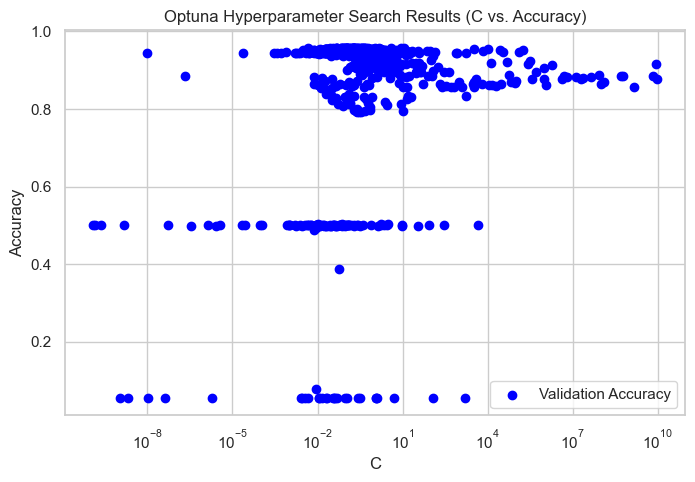

In [58]:
# 6. Plotting search results
# Manually collect trials
study = optuna_search_svm.study_

# Access the correct parameters based on your SVM model
trial_params_C = [trial.params['C'] for trial in study.trials]
trial_params_gamma = [trial.params['gamma'] for trial in study.trials]
trial_scores = [trial.value for trial in study.trials]

# Example: Plot C vs. Accuracy
plt.figure(figsize=(8, 5))
plt.scatter(trial_params_C, trial_scores, color='blue', label='Validation Accuracy')
plt.xscale('log')
plt.xlabel('C')  # X-axis label for C
plt.ylabel('Accuracy')
plt.title('Optuna Hyperparameter Search Results (C vs. Accuracy)')
plt.legend()
plt.grid(True)
plt.show()

# You can similarly plot for 'gamma' or other hyperparameters


Test Set Metrics (OptunaSearch):
Precision: 0.95
Recall: 0.95
F1-Score: 0.94


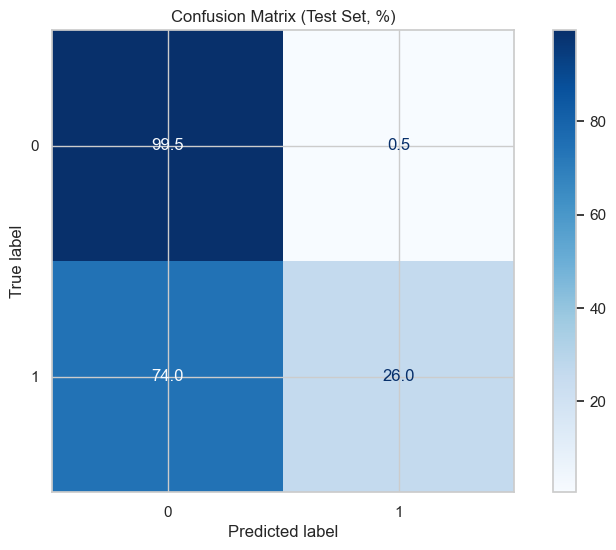


Classification Report (Test Set - OptunaSearch):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       846
           1       0.76      0.26      0.39        50

    accuracy                           0.95       896
   macro avg       0.86      0.63      0.68       896
weighted avg       0.95      0.95      0.94       896



In [59]:
y_test_pred_optuna = optuna_search_svm.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred_optuna, average='weighted')
conf_matrix_test_optuna = confusion_matrix(y_test, y_test_pred_optuna)

print(f"\nTest Set Metrics (OptunaSearch):")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

cm_percent = conf_matrix_test_optuna.astype('float') / conf_matrix_test_optuna.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=optuna_search_svm.classes_)
disp.plot(cmap='Blues', values_format=".1f")
plt.title("Confusion Matrix (Test Set, %)")
plt.show()

print("\nClassification Report (Test Set - OptunaSearch):")
print(classification_report(y_test, y_test_pred_optuna))

model was compromised by the feature reduction and accuracy was decraesd by 1.2

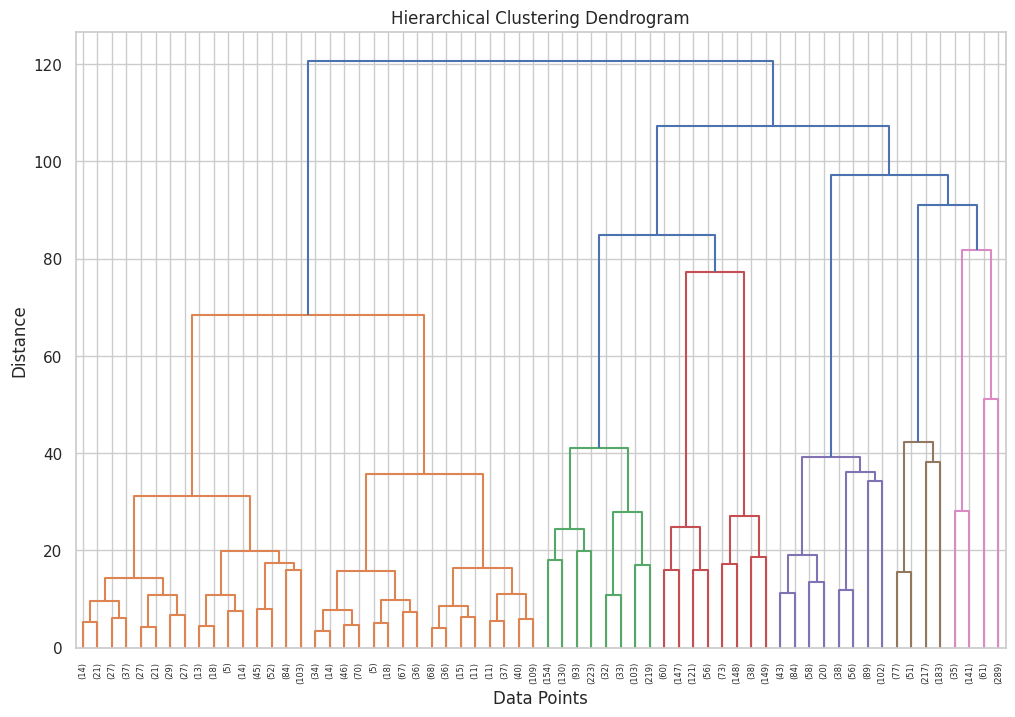

In [ ]:
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

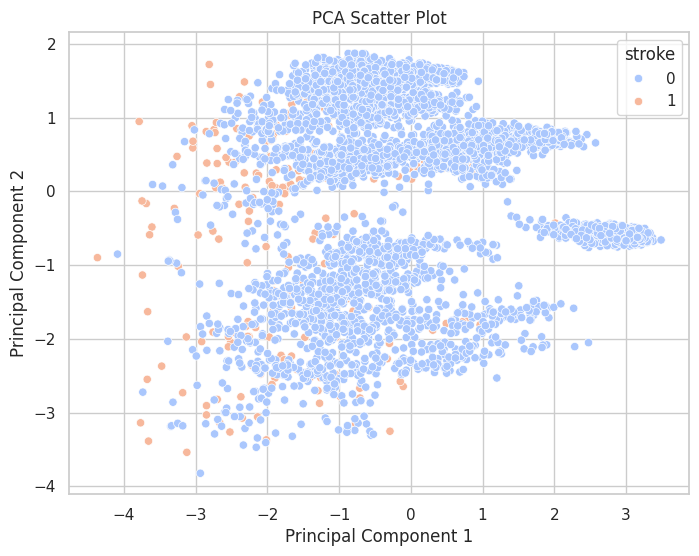

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm')
plt.title("PCA Scatter Plot")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()